## 1. Configuração do Ambiente Analítico

Nesta seção são importadas todas as bibliotecas necessárias para a execução do estudo. As dependências contemplam:

- Manipulação e preparação dos dados;
- Visualização exploratória;
- Implementação dos algoritmos de classificação;
- Avaliação de desempenho por múltiplas métricas;
- Técnicas de balanceamento de classes;
- Métodos de interpretabilidade baseados em SHAP e LIME.

Essa etapa assegura a padronização do ambiente experimental e contribui para a reprodutibilidade dos resultados obtidos na modelagem de churn.

In [1]:
# [FUNÇÃO TÉCNICA] - Importa a biblioteca NumPy para operações numéricas eficientes com arrays multidimensionais.
import numpy as np

# [FUNÇÃO TÉCNICA] - Importa Matplotlib para criação de gráficos e visualizações.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Importa Seaborn para visualizações estatísticas avançadas baseadas em Matplotlib.
import seaborn as sns

# [FUNÇÃO TÉCNICA] - Importa funções de divisão de dados e validação cruzada estratificada do Scikit-learn.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# [FUNÇÃO TÉCNICA] - Importa LabelEncoder para codificação de variáveis categóricas em numéricas.
from sklearn.preprocessing import LabelEncoder

# [FUNÇÃO TÉCNICA] - Importa métricas de avaliação para classificação, incluindo precisão, recall, F1-score e AUC.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             matthews_corrcoef, confusion_matrix,
                             classification_report)


# [FUNÇÃO TÉCNICA] - Importa RandomForestClassifier para modelagem baseada em ensemble de árvores de decisão.
from sklearn.ensemble import RandomForestClassifier

# [FUNÇÃO TÉCNICA] - Importa LogisticRegression para modelagem linear probabilística.
from sklearn.linear_model import LogisticRegression

# [FUNÇÃO TÉCNICA] - Importa XGBoost para gradient boosting otimizado.
import xgboost as xgb

# [FUNÇÃO TÉCNICA] - Importa LightGBM para gradient boosting eficiente em grandes datasets.
import lightgbm as lgb

# [FUNÇÃO TÉCNICA] - Importa CatBoost para gradient boosting com tratamento automático de categóricas.
from catboost import CatBoostClassifier

# [FUNÇÃO TÉCNICA] - Importa SMOTE para oversampling sintético da classe minoritária.
from imblearn.over_sampling import SMOTE

# [FUNÇÃO TÉCNICA] - Importa SHAP para explicabilidade baseada em valores Shapley.
import shap

# [FUNÇÃO TÉCNICA] - Importa LIME para explicabilidade local através de aproximações lineares.
from lime.lime_tabular import LimeTabularExplainer

# [FUNÇÃO TÉCNICA] - Importa módulo warnings para controle de avisos.
import warnings

# [FUNÇÃO TÉCNICA] - Desabilita avisos para execução limpa.
warnings.filterwarnings('ignore')

# [FUNÇÃO TÉCNICA] - Imprime confirmação de importações bem-sucedidas.
print("✅ Importações realizadas com sucesso!")

# [FUNÇÃO TÉCNICA] - Exibe versão do NumPy para documentação.
print(f"NumPy: {np.__version__}")

# [FUNÇÃO TÉCNICA] - Exibe versão do Scikit-learn.
print(f"Scikit-learn: {__import__('sklearn').__version__}")

# [FUNÇÃO TÉCNICA] - Exibe versão do Imbalanced-learn.
print(f"Imbalanced-learn: {__import__('imblearn').__version__}")

✅ Importações realizadas com sucesso!
NumPy: 1.26.4
Scikit-learn: 1.3.2
Imbalanced-learn: 0.11.0


## 2 – Carregamento da base Telco

**Carregar dados do Google Drive via link público**

Certifique-se de seguir os passos acima para tornar o arquivo público no Google Drive e obter o ID do arquivo.

In [2]:
# [FUNÇÃO TÉCNICA] - Importa a biblioteca Pandas para manipulação de dados tabulares.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Define o ID do arquivo no Google Sheets para download.
file_id = "1D2CnBF-I_Bxqk4Kv6DGqRf3voac6i8Hp"

# [FUNÇÃO TÉCNICA] - Constrói a URL de download do arquivo CSV a partir do Google Sheets.
download_url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv"

# [FUNÇÃO TÉCNICA] - Carrega o dataset a partir da URL CSV utilizando Pandas.
df = pd.read_csv(download_url)

# [FUNÇÃO TÉCNICA] - Imprime as dimensões do DataFrame (linhas e colunas).
print("Shape:", df.shape)

# [FUNÇÃO TÉCNICA] - Exibe as primeiras linhas do DataFrame para inspeção inicial.
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,...,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,...,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,...,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,...,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293","34,039224","-118,266293",Male,...,Month-to-month,Yes,Bank transfer (automatic),"103,7","5036,3",Yes,1,89,5340,Competitor had better devices


## 3 – Tratamento da variável TotalCharges



Nesta etapa, realizamos a conversão da variável TotalCharges para formato numérico.
Ponto importante: Para evitar vazamento de dados (data leakage), foi realizado a divisão dos dados em conjuntos de treino e teste (80/20) antes de imputar os valores ausentes. A mediana utilizada para preencher os dados faltantes é calculada exclusivamente sobre o conjunto de treino e, em seguida, aplicada a ambos os conjuntos.

In [3]:
# [FUNÇÃO TÉCNICA] - Importa Pandas para manipulação de dados.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa NumPy para operações numéricas.
import numpy as np

# [FUNÇÃO TÉCNICA] - Importa função de divisão de dados do Scikit-learn.
from sklearn.model_selection import train_test_split


# [FUNÇÃO TÉCNICA] - Padroniza nomes das colunas removendo espaços e substituindo por underscores.
df.columns = df.columns.str.strip().str.replace(" ", "_")


# --- AJUSTE PARA O ERRO '70,7' ---

# [FUNÇÃO TÉCNICA] - Comentário para garantia de substituição de vírgulas por pontos.
# 2. Garantir que vírgulas sejam pontos em colunas numéricas críticas

# [FUNÇÃO TÉCNICA] - Define lista de colunas a ajustar.
cols_ajustar = ["Total_Charges", "Monthly_Charges"]

# [FUNÇÃO TÉCNICA] - Inicia loop para ajustar cada coluna.
for col in cols_ajustar:

    # [FUNÇÃO TÉCNICA] - Verifica se a coluna existe no DataFrame.
    if col in df.columns:

        # [FUNÇÃO TÉCNICA] - Substitui vírgulas por pontos na coluna.
        df[col] = df[col].astype(str).str.replace(',', '.')


# [FUNÇÃO TÉCNICA] - Converte Total_Charges para numérico.
df["Total_Charges"] = pd.to_numeric(df["Total_Charges"], errors='coerce')

# [FUNÇÃO TÉCNICA] - Converte Monthly_Charges para numérico.
df["Monthly_Charges"] = pd.to_numeric(df["Monthly_Charges"], errors='coerce')

# [FUNÇÃO TÉCNICA] - Fim do ajuste.


# [FUNÇÃO TÉCNICA] - Define y como variável binária baseada em Churn_Label.
y = (df["Churn_Label"] == "Yes").astype(int)


# [FUNÇÃO TÉCNICA] - Define lista de colunas a remover.
colunas_para_remover = [
    "Churn_Label", "Churn_Value", "Churn_Reason", "Churn_Score", "CLTV",
    "CustomerID", "Count", "Country", "State", "City", "Zip_Code", 
    "Lat_Long", "Latitude", "Longitude"
]

# [FUNÇÃO TÉCNICA] - Remove colunas irrelevantes para criar X.
X = df.drop(columns=colunas_para_remover, errors='ignore')

# 6. Divisão em conjuntos de treino e teste

# [FUNÇÃO TÉCNICA] - Divide os dados em treino e teste de forma estratificada.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 7. Calcular mediana APENAS no treino para evitar data leakage

# [FUNÇÃO TÉCNICA] - Calcula mediana de Total_Charges no conjunto de treino.
mediana_treino = X_train["Total_Charges"].median()

# 8. Aplicar imputação

# [FUNÇÃO TÉCNICA] - Preenche valores ausentes em X_train com a mediana.
X_train["Total_Charges"] = X_train["Total_Charges"].fillna(mediana_treino)

# [FUNÇÃO TÉCNICA] - Preenche valores ausentes em X_test com a mediana.
X_test["Total_Charges"] = X_test["Total_Charges"].fillna(mediana_treino)

# [FUNÇÃO TÉCNICA] - Imprime confirmação de correção.
print("✅ Bloco 3 corrigido: Vírgulas tratadas e divisão realizada.")

# [FUNÇÃO TÉCNICA] - Imprime shape do X_train.
print(f"Shape do X_train: {X_train.shape}")

✅ Bloco 3 corrigido: Vírgulas tratadas e divisão realizada.
Shape do X_train: (5634, 19)


## 4 – Análise de Desbalanceamento da Variável Alvo

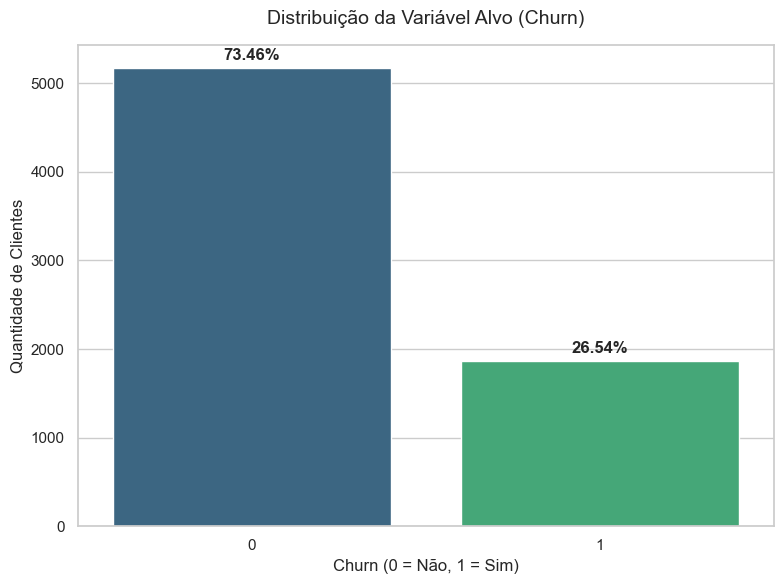

Distribuição das Classes:
Churn_Value
0    5174
1    1869
Name: count, dtype: int64

Porcentagem das Classes:
Churn_Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [4]:

# Análise de Desbalanceamento da Variável Alvo

# [FUNÇÃO TÉCNICA] - Importa Matplotlib para plotagem.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Importa Seaborn para visualizações estatísticas.
import seaborn as sns

# [FUNÇÃO TÉCNICA] - Configura o estilo visual do Seaborn.
sns.set_theme(style="whitegrid")

# [FUNÇÃO TÉCNICA] - Define o tamanho da figura.
plt.figure(figsize=(8, 6))

# [FUNÇÃO TÉCNICA] - Geração do gráfico.
ax = sns.countplot(x='Churn_Value', data=df, palette='viridis')

# [FUNÇÃO TÉCNICA] - Adição de título e rótulos.
plt.title('Distribuição da Variável Alvo (Churn)', fontsize=14, pad=15)

plt.xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)

plt.ylabel('Quantidade de Clientes', fontsize=12)

# [FUNÇÃO TÉCNICA] - Adição de porcentagens.
total = len(df)

for p in ax.patches:

    height = p.get_height()

    percentage = '{:1.2%}'.format(height/total)

    ax.annotate(percentage, 

                (p.get_x() + p.get_width() / 2., height), 

                ha = 'center', va = 'center', 

                xytext = (0, 9), 

                textcoords = 'offset points',

                fontsize=12, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Ajusta o layout da figura.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

# [FUNÇÃO TÉCNICA] - Impressão de valores exatos.
print("Distribuição das Classes:")

print(df['Churn_Value'].value_counts())

print("\nPorcentagem das Classes:")

print(df['Churn_Value'].value_counts(normalize=True) * 100)

## 5 – Engenharia de Atributos (Feature Engineering)

Na sequência, foi contruido seis variáveis derivadas para incorporar conhecimento de negócio (como Average_Monthly_Charge, Contract_Tenure_Ratio, etc.).

Para garantir a integridade do processo, aplicamos essas transformações separadamente nos dados de treino e teste. O limiar para definir um High_Value_Customer (baseado no quantil 0.75) é calculado usando apenas os dados de treino, garantindo que o modelo não tenha acesso a estatísticas globais do conjunto de teste.


In [5]:
# [FUNÇÃO TÉCNICA] - Inicia loop para garantir que colunas monetárias estejam em formato numérico.
for col in ['Total_Charges', 'Monthly_Charges']:

    # [FUNÇÃO TÉCNICA] - Verifica se a coluna existe no conjunto de treino.
    if col in X_train.columns:

        # [FUNÇÃO TÉCNICA] - Substitui vírgulas por pontos na coluna do treino.
        X_train[col] = (
            X_train[col].astype(str).str.replace(",", ".", regex=False)
        )

        # [FUNÇÃO TÉCNICA] - Substitui vírgulas por pontos na coluna do teste.
        X_test[col] = (
            X_test[col].astype(str).str.replace(",", ".", regex=False)
        )

        # [FUNÇÃO TÉCNICA] - Converte a coluna do treino para numérico.
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')

        # [FUNÇÃO TÉCNICA] - Converte a coluna do teste para numérico.
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# [FUNÇÃO TÉCNICA] - Define função para criar novas features derivadas.
def criar_features(dados, limiar_valor=None):

    # [FUNÇÃO TÉCNICA] - Cria cópia dos dados para evitar modificações no original.
    df_temp = dados.copy()

    # [FUNÇÃO TÉCNICA] - Define o nome da coluna de tempo de contrato.
    tenure_col = 'Tenure_Months'

    # [FUNÇÃO TÉCNICA] - Calcula a média mensal de cobrança.
    df_temp['Average_Monthly_Charge'] = (
        df_temp['Total_Charges'] / (df_temp[tenure_col] + 1)
    )

    # [FUNÇÃO TÉCNICA] - Define lista de colunas de serviços.
    service_cols = [
        'Phone_Service', 'Multiple_Lines',
        'Online_Security', 'Online_Backup',
        'Device_Protection', 'Tech_Support',
        'Streaming_TV', 'Streaming_Movies'
    ]

    # [FUNÇÃO TÉCNICA] - Filtra colunas de serviços que existem no DataFrame.
    service_cols = [c for c in service_cols if c in df_temp.columns]

    # [FUNÇÃO TÉCNICA] - Conta o número de serviços contratados.
    df_temp['Service_Count'] = (
        df_temp[service_cols]
        .apply(lambda row: (row == 'Yes').sum(), axis=1)
    )

    # [FUNÇÃO TÉCNICA] - Define mapeamento para duração dos contratos.
    contract_map = {
        'Month-to-month': 1,
        'One year': 12,
        'Two year': 24
    }

    # [FUNÇÃO TÉCNICA] - Calcula a razão entre tempo de contrato e duração do plano.
    df_temp['Contract_Tenure_Ratio'] = (
        df_temp[tenure_col] /
        df_temp['Contract'].map(contract_map)
    )

    # [FUNÇÃO TÉCNICA] - Calcula cobrança mensal por serviço.
    df_temp['Monthly_Per_Service'] = (
        df_temp['Monthly_Charges'] /
        (df_temp['Service_Count'] + 1)
    )

    # [FUNÇÃO TÉCNICA] - Verifica se a coluna Senior_Citizen existe.
    if 'Senior_Citizen' in df_temp.columns:

        # [FUNÇÃO TÉCNICA] - Cria feature para idosos com múltiplos serviços.
        df_temp['Senior_Multiple_Services'] = (
            (df_temp['Senior_Citizen'] == 'Yes') &
            (df_temp['Service_Count'] > 2)
        ).astype(int)

    # [FUNÇÃO TÉCNICA] - Verifica se limiar de valor foi fornecido.
    if limiar_valor is not None:

        # [FUNÇÃO TÉCNICA] - Cria feature para clientes de alto valor.
        df_temp['High_Value_Customer'] = (
            df_temp['Monthly_Charges'] > limiar_valor
        ).astype(int)

    # [FUNÇÃO TÉCNICA] - Retorna o DataFrame com novas features.
    return df_temp

# [FUNÇÃO TÉCNICA] - Calcula o limiar de cobrança mensal no conjunto de treino.
threshold_treino = X_train['Monthly_Charges'].quantile(0.75)

# [FUNÇÃO TÉCNICA] - Aplica engenharia de features no conjunto de treino.
X_train = criar_features(X_train, limiar_valor=threshold_treino)

# [FUNÇÃO TÉCNICA] - Aplica engenharia de features no conjunto de teste.
X_test = criar_features(X_test, limiar_valor=threshold_treino)

# [FUNÇÃO TÉCNICA] - Imprime confirmação de aplicação da engenharia.
print("Engenharia aplicada com sucesso.")

# [FUNÇÃO TÉCNICA] - Exibe primeiras linhas das novas features.
print(X_train[['Average_Monthly_Charge',
               'Service_Count',
               'High_Value_Customer']].head())

Engenharia aplicada com sucesso.
      Average_Monthly_Charge  Service_Count  High_Value_Customer
4626               47.268056              3                    0
4192               71.971875              2                    0
5457               42.167857              3                    0
4717               70.581481              5                    0
4673               22.275000              1                    0


## 6 – Pré-processamento: Encoding (One-Hot e StandardScaler)

Para viabilizar o uso dos algoritmos de aprendizado de máquina, as variáveis categóricas foram transformadas por meio de One-Hot Encoding, enquanto as variáveis numéricas foram padronizadas com StandardScaler. O ajuste (fit) do pré-processador foi realizado exclusivamente sobre o conjunto de treino, sendo posteriormente aplicado (transform) ao conjunto de teste, evitando qualquer forma de vazamento de dados.


In [6]:
# [FUNÇÃO TÉCNICA] - Importa ColumnTransformer para transformação de colunas.
from sklearn.compose import ColumnTransformer

# [FUNÇÃO TÉCNICA] - Importa OneHotEncoder e StandardScaler para pré-processamento.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# [FUNÇÃO TÉCNICA] - Importa NumPy para tipos de dados.
import numpy as np

# [FUNÇÃO TÉCNICA] - Identifica colunas numéricas no conjunto de treino.
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# [FUNÇÃO TÉCNICA] - Identifica colunas categóricas no conjunto de treino.
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# [FUNÇÃO TÉCNICA] - Imprime colunas numéricas identificadas.
print(f"Colunas numéricas ({len(num_cols)}): {num_cols}")

# [FUNÇÃO TÉCNICA] - Imprime colunas categóricas identificadas.
print(f"Colunas categóricas ({len(cat_cols)}): {cat_cols}")

# [FUNÇÃO TÉCNICA] - Cria ColumnTransformer para pré-processamento.
preprocess_rf_xgb_lgb = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='passthrough')

# [FUNÇÃO TÉCNICA] - Ajusta e transforma o conjunto de treino.
X_train_enc = preprocess_rf_xgb_lgb.fit_transform(X_train)

# [FUNÇÃO TÉCNICA] - Transforma o conjunto de teste.
X_test_enc = preprocess_rf_xgb_lgb.transform(X_test)

# [FUNÇÃO TÉCNICA] - Obtém nomes das features após encoding.
feature_names_enc = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Imprime shape do treino após encoding.
print(f"\nShape de X_train após encoding: {X_train_enc.shape}")

# [FUNÇÃO TÉCNICA] - Imprime shape do teste após encoding.
print(f"Shape de X_test após encoding: {X_test_enc.shape}")

# [FUNÇÃO TÉCNICA] - Imprime total de features codificadas.
print(f"Total de features codificadas: {len(feature_names_enc)}")

Colunas numéricas (9): ['Tenure_Months', 'Monthly_Charges', 'Total_Charges', 'Average_Monthly_Charge', 'Service_Count', 'Contract_Tenure_Ratio', 'Monthly_Per_Service', 'Senior_Multiple_Services', 'High_Value_Customer']
Colunas categóricas (16): ['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method']

Shape de X_train após encoding: (5634, 52)
Shape de X_test após encoding: (1409, 52)
Total de features codificadas: 52


## 7 – Pipeline SMOTE para Balanceamento de Classes

Para evitar a fuga de dados (data leakage), o balanceamento com SMOTE foi embutido num Pipeline. Desta forma, a geração de dados sintéticos ocorre exclusivamente nas fatias de treino durante a validação cruzada. A fatia de validação permanece totalmente isolada e apenas com dados reais, garantindo o rigor metodológico e a fiabilidade das métricas.

In [7]:
# [FUNÇÃO TÉCNICA] - Importa Pipeline do imblearn para incluir SMOTE.
from imblearn.pipeline import Pipeline as ImbPipeline

# [FUNÇÃO TÉCNICA] - Importa SMOTE para oversampling.
from imblearn.over_sampling import SMOTE

# [FUNÇÃO TÉCNICA] - Importa StratifiedKFold e GridSearchCV para validação.
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# [FUNÇÃO TÉCNICA] - Importa RandomForestClassifier.
from sklearn.ensemble import RandomForestClassifier

# [FUNÇÃO TÉCNICA] - Configura validação cruzada estratificada.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# [FUNÇÃO TÉCNICA] - Cria pipeline com SMOTE e RandomForest.
pipeline_rf = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('modelo_rf', RandomForestClassifier(random_state=42))
])

# [FUNÇÃO TÉCNICA] - Define grade de parâmetros para o modelo.
param_grid = {
    'modelo_rf__n_estimators': [100, 200],
    'modelo_rf__max_depth': [5, 10]
}

# [FUNÇÃO TÉCNICA] - Configura GridSearchCV com o pipeline.
grid_rf = GridSearchCV(
    estimator=pipeline_rf, # Passa o pipeline (que contém o SMOTE)
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1
)

# [FUNÇÃO TÉCNICA] - Treina o modelo com dados codificados.
grid_rf.fit(X_train_enc, y_train)

# [FUNÇÃO TÉCNICA] - Imprime melhores parâmetros encontrados.
print("Melhores parâmetros encontrados:", grid_rf.best_params_)

Melhores parâmetros encontrados: {'modelo_rf__max_depth': 5, 'modelo_rf__n_estimators': 100}


## 8 – Pipeline de Modelagem e Validação Cruzada

Nesta etapa, implementamos o fluxo de treinamento utilizando o `Pipeline` da biblioteca `imbalanced-learn`. Conforme descrito na metodologia (Seção 3.4), o uso do pipeline é fundamental para garantir o rigor acadêmico, pois assegura que:
1. A **Transformação de Dados** (One-Hot Encoding e Scaling) seja aplicada de forma consistente.
2. O **Balanceamento com SMOTE** ocorra exclusivamente nos dados de treino de cada dobra da validação cruzada, eliminando o risco de vazamento de dados (*data leakage*).
3. A **Validação Cruzada Estratificada** forneça métricas de desempenho realistas para dados desbalanceados.

In [8]:
# [FUNÇÃO TÉCNICA] - Importa bibliotecas necessárias para pipelines.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa NumPy.
import numpy as np

# [FUNÇÃO TÉCNICA] - Importa Pipeline do imblearn.
from imblearn.pipeline import Pipeline as ImbPipeline

# [FUNÇÃO TÉCNICA] - Importa SMOTE.
from imblearn.over_sampling import SMOTE

# [FUNÇÃO TÉCNICA] - Importa ColumnTransformer.
from sklearn.compose import ColumnTransformer

# [FUNÇÃO TÉCNICA] - Importa OneHotEncoder e StandardScaler.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# [FUNÇÃO TÉCNICA] - Importa StratifiedKFold e cross_validate.
from sklearn.model_selection import StratifiedKFold, cross_validate

# [FUNÇÃO TÉCNICA] - Define lista de features numéricas.
features_numericas = [
    'Tenure_Months', 'Monthly_Charges', 'Total_Charges', 
    'Average_Monthly_Charge', 'Service_Count', 
    'Contract_Tenure_Ratio', 'Monthly_Per_Service'
]

# [FUNÇÃO TÉCNICA] - Define colunas a ignorar.
colunas_para_ignorar = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 
    'Lat_Long', 'Latitude', 'Longitude', 'Churn_Label', 'Churn_Value', 
    'Churn_Score', 'CLTV', 'Churn_Reason'
]

# [FUNÇÃO TÉCNICA] - Identifica features categóricas.
features_categoricas = [c for c in df.columns if c not in features_numericas + colunas_para_ignorar]

# [FUNÇÃO TÉCNICA] - Cria pré-processador com transformadores.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [c for c in features_numericas if c in df.columns]),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), features_categoricas)
    ])

# [FUNÇÃO TÉCNICA] - Define função para criar pipeline com algoritmo.
def criar_pipeline(algoritmo):
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', algoritmo)
    ])

# [FUNÇÃO TÉCNICA] - Define X removendo colunas ignoradas.
X = df.drop(columns=colunas_para_ignorar, errors='ignore')

# [FUNÇÃO TÉCNICA] - Define y como Churn_Value.
y = df['Churn_Value'] 

# [FUNÇÃO TÉCNICA] - Configura validação cruzada estratificada.
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 9 – Visualização de Correlação (Heatmap)

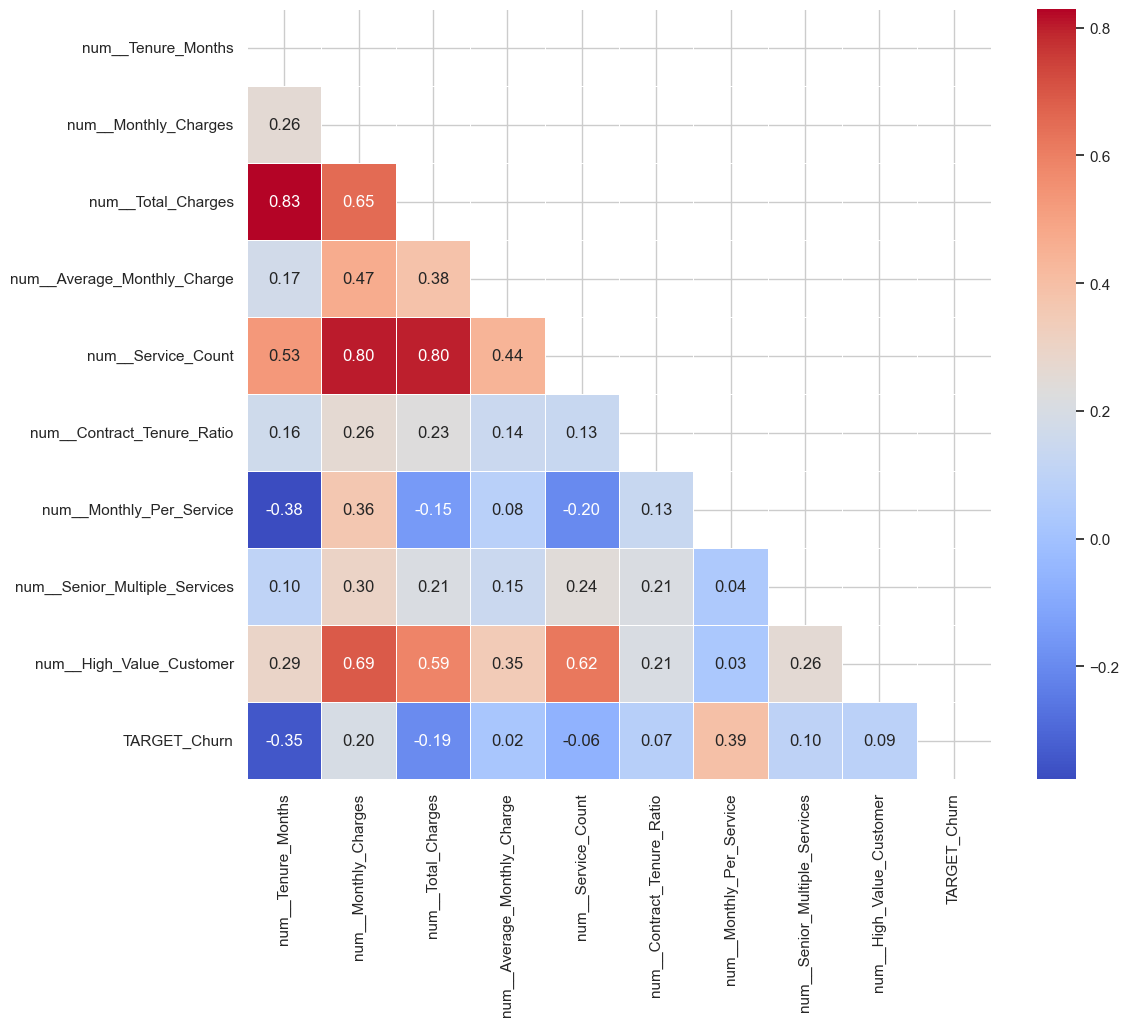

In [9]:
# [FUNÇÃO TÉCNICA] - Importa Seaborn para visualizações.
import seaborn as sns

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Importa NumPy.
import numpy as np

# [FUNÇÃO TÉCNICA] - Cria DataFrame com features codificadas.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Cria DataFrame para correlação.
df_corr = pd.DataFrame(X_train_enc, columns=feature_names)

# [FUNÇÃO TÉCNICA] - Adiciona variável alvo ao DataFrame.
df_corr['TARGET_Churn'] = y_train.values

# [FUNÇÃO TÉCNICA] - Calcula matriz de correlação.
corr_matrix = df_corr.corr()

# [FUNÇÃO TÉCNICA] - Seleciona colunas de interesse para matriz resumida.
cols_interesse = [c for c in df_corr.columns if 'num__' in c] + ['TARGET_Churn']

# [FUNÇÃO TÉCNICA] - Calcula matriz resumida de correlação.
matriz_resumida = df_corr[cols_interesse].corr()

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 10))

# [FUNÇÃO TÉCNICA] - Cria máscara para triangular superior.
mask = np.triu(np.ones_like(matriz_resumida, dtype=bool))

# [FUNÇÃO TÉCNICA] - Plota heatmap de correlação.
sns.heatmap(
     matriz_resumida,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
    )
plt.show()

## 10 – Função Auxiliar: avalia_modelo()

Para padronizar a comparação entre os modelos, foi criada uma função auxiliar que executa o GridSearchCV com validação cruzada estratificada em 5 folds sobre o conjunto de treino balanceado por SMOTE. Em seguida, o melhor modelo encontrado é ajustado aos dados de treino e avaliado no conjunto de teste independente, utilizando a versão codificada das variáveis preditoras. O sistema de avaliação considera múltiplas métricas adequadas a contextos desbalanceados, incluindo acurácia, precisão, recall, F1‑Score, AUC‑ROC, AUC‑PR e Matthews Correlation Coefficient (MCC).

In [10]:
# [FUNÇÃO TÉCNICA] - Importa GridSearchCV.
from sklearn.model_selection import GridSearchCV

# [FUNÇÃO TÉCNICA] - Importa métricas de avaliação.
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    average_precision_score, confusion_matrix
)

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Importa Seaborn.
import seaborn as sns

# [FUNÇÃO TÉCNICA] - Importa Pipeline do imblearn.
from imblearn.pipeline import Pipeline as ImbPipeline

# [FUNÇÃO TÉCNICA] - Importa SMOTE.
from imblearn.over_sampling import SMOTE

# [FUNÇÃO TÉCNICA] - Define função para avaliar modelo.
def avalia_modelo(nome, modelo, param_grid, X_tr, y_tr, X_te, y_te, scoring='f1'):
    """
    Função com Pipeline anti-vazamento de dados (SMOTE dentro do Cross-Validation).
    Aceita param_grid como dicionário simples ou lista de dicionários.
    """

    # [FUNÇÃO TÉCNICA] - Verifica se param_grid é lista ou dicionário.
    if isinstance(param_grid, list):
        # [FUNÇÃO TÉCNICA] - Trata lista de dicionários (ex: Regressão Logística).
        new_param_grid = [
            {f'model__{key}': value for key, value in d.items()}
            for d in param_grid
        ]
    else:
        # [FUNÇÃO TÉCNICA] - Trata dicionário simples (ex: Random Forest, XGBoost).
        new_param_grid = {f'model__{key}': value for key, value in param_grid.items()}

    # [FUNÇÃO TÉCNICA] - Cria pipeline com SMOTE e modelo.
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', modelo)
    ])

    # [FUNÇÃO TÉCNICA] - Configura GridSearchCV.
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=new_param_grid,
        cv=5,
        scoring=scoring,
        n_jobs=1,
        verbose=0
    )

    # [FUNÇÃO TÉCNICA] - Treina o grid.
    grid.fit(X_tr, y_tr)

    # [FUNÇÃO TÉCNICA] - Obtém melhor pipeline.
    best_pipeline = grid.best_estimator_

    # [FUNÇÃO TÉCNICA] - Faz previsões no teste.
    y_pred = best_pipeline.predict(X_te)

    # [FUNÇÃO TÉCNICA] - Tenta obter probabilidades.
    try:
        y_prob = best_pipeline.predict_proba(X_te)[:, 1]
    except AttributeError:
        y_prob = y_pred

    # [FUNÇÃO TÉCNICA] - Calcula métricas.
    metrics = {
        'Modelo': nome,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC-ROC': roc_auc_score(y_te, y_prob) if y_prob is not None else 0,
        'AUC-PR': average_precision_score(y_te, y_prob) if y_prob is not None else 0,
        'MCC': matthews_corrcoef(y_te, y_pred)
    }

    # [FUNÇÃO TÉCNICA] - Calcula matriz de confusão.
    cm = confusion_matrix(y_te, y_pred)

    # [FUNÇÃO TÉCNICA] - Plota matriz de confusão.
    plt.figure(figsize=(6, 4))

    # [FUNÇÃO TÉCNICA] - Cria heatmap da matriz.
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Não Churn', 'Churn'],
                yticklabels=['Não Churn', 'Churn'])

    # [FUNÇÃO TÉCNICA] - Define título do gráfico.
    plt.title(f'Matriz de Confusão – {nome}', fontsize=12)

    # [FUNÇÃO TÉCNICA] - Define rótulo do eixo Y.
    plt.ylabel('Classe Real')

    # [FUNÇÃO TÉCNICA] - Define rótulo do eixo X.
    plt.xlabel('Classe Prevista')

    # [FUNÇÃO TÉCNICA] - Exibe o gráfico.
    plt.show()

    # [FUNÇÃO TÉCNICA] - Imprime resultados.
    print(f"\n{'='*20} Resultados: {nome} {'='*20}")

    # [FUNÇÃO TÉCNICA] - Imprime métricas formatadas.
    for key, value in metrics.items():
        if key != 'Modelo':
            print(f"  {key:<12}: {value:.4f}")

    # [FUNÇÃO TÉCNICA] - Retorna melhor pipeline e métricas.
    return best_pipeline, metrics

## 11 – Regressão Logística (Baseline)

O primeiro modelo ajustado é a **Regressão Logística**, estabelecendo um baseline
interpretável para comparação com modelos mais complexos. Este modelo linear clássico
para classificação binária oferece coeficientes diretamente interpretáveis, permitindo
entender o impacto de cada variável na probabilidade de churn.

São otimizados hiperparâmetros relacionados à regularização (C), tipo de penalização
(L1 ou L2) e algoritmo de otimização (solver), utilizando o conjunto de treino
balanceado por SMOTE e a versão codificada das variáveis preditoras, com validação
cruzada estratificada em 5 folds. O desempenho final é avaliado no conjunto de teste
independente.

**Vantagens da Regressão Logística:**
- Interpretabilidade direta via coeficientes
- Velocidade de treinamento (segundos vs minutos)
- Menor risco de overfitting
- Simplicidade de implementação e manutenção

**Hiperparâmetros otimizados:**
- **C**: Inverso da força de regularização (menor C = mais regularização)
- **penalty**: Tipo de penalização (L1 para seleção de features, L2 para regularização geral)
- **solver**: Algoritmo de otimização (liblinear e saga são compatíveis com L1 e L2)

Treinando Regressão Logística...


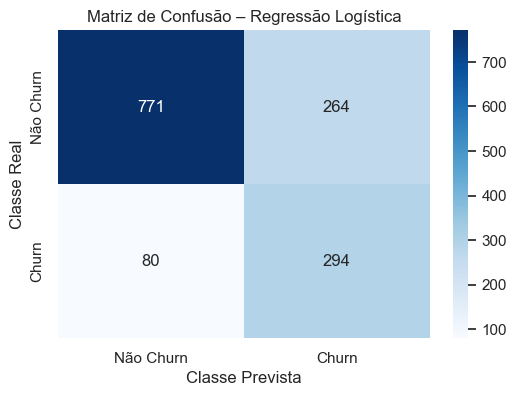


==================== Resultados: Regressão Logística ====================
  Accuracy    : 0.7559
  Precision   : 0.5269
  Recall      : 0.7861
  F1          : 0.6309
  AUC-ROC     : 0.8522
  AUC-PR      : 0.6629
  MCC         : 0.4794
MELHORES HIPERPARÂMETROS COMPLETOS – REGRESSÃO LOGÍSTICA
   Hiperparâmetro   Valor
                C     0.1
     class_weight    None
             dual   False
    fit_intercept    True
intercept_scaling       1
         l1_ratio    None
         max_iter    2000
      multi_class    auto
           n_jobs    None
          penalty      l2
     random_state      42
           solver   lbfgs
              tol  0.0001
          verbose       0
       warm_start   False


In [11]:
# [FUNÇÃO TÉCNICA] - Instala tabulate para tabelas.
!pip install tabulate

# [FUNÇÃO TÉCNICA] - Importa LogisticRegression.
from sklearn.linear_model import LogisticRegression

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Define parâmetros para grid search com combinações válidas.
param_lr = [
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    },
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver': ['liblinear']
    }
]

# [FUNÇÃO TÉCNICA] - Instancia modelo de regressão logística.
lr = LogisticRegression(random_state=42, max_iter=2000)

# [FUNÇÃO TÉCNICA] - Imprime mensagem de treinamento.
print("Treinando Regressão Logística...")

# [FUNÇÃO TÉCNICA] - Chama função de avaliação para regressão logística.
best_lr, met_lr = avalia_modelo(
    "Regressão Logística",
    lr,
    param_lr,
    X_train_enc,
    y_train,
    X_test_enc,
    y_test
)

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Imprime título.
print("MELHORES HIPERPARÂMETROS COMPLETOS – REGRESSÃO LOGÍSTICA")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Extrai modelo do pipeline.
lr_model = best_lr.named_steps['model']

# [FUNÇÃO TÉCNICA] - Obtém todos os parâmetros.
params_completos = lr_model.get_params()

# [FUNÇÃO TÉCNICA] - Cria DataFrame com parâmetros.
df_params = pd.DataFrame(
    list(params_completos.items()),
    columns=['Hiperparâmetro', 'Valor']
).sort_values('Hiperparâmetro')

# [FUNÇÃO TÉCNICA] - Configura opções de exibição.
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

# [FUNÇÃO TÉCNICA] - Imprime DataFrame.
print(df_params.to_string(index=False))

# [FUNÇÃO TÉCNICA] - Reseta opções.
pd.reset_option('display.max_colwidth')
pd.reset_option('display.width')

# [FUNÇÃO TÉCNICA] - Imprime separador final.
print("="*80)

## 12 – Random Forest


O primeiro modelo ajustado é o Random Forest, utilizado como baseline baseado em árvores. São otimizados hiperparâmetros relacionados ao número de árvores, profundidade máxima e critérios de divisão, utilizando o conjunto de treino balanceado por SMOTE e a versão codificada das variáveis preditoras, com validação cruzada estratificada em 5 folds. O desempenho final é avaliado no conjunto de teste independente, com base nas métricas de acurácia, precisão, recall, F1‑Score, AUC‑ROC, AUC‑PR e MCC.​



Treinando Random Forest...


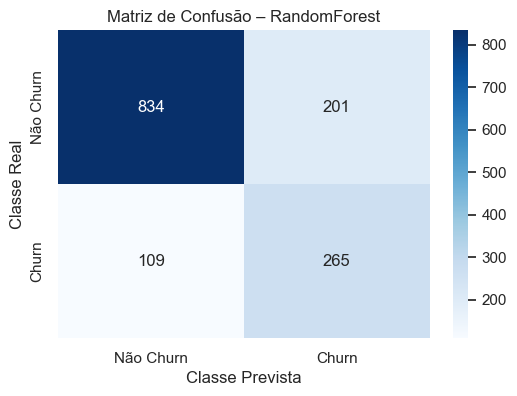


==================== Resultados: RandomForest ====================
  Accuracy    : 0.7800
  Precision   : 0.5687
  Recall      : 0.7086
  F1          : 0.6310
  AUC-ROC     : 0.8461
  AUC-PR      : 0.6506
  MCC         : 0.4827
MELHORES HIPERPARÂMETROS COMPLETOS – RANDOM FOREST
          Hiperparâmetro Valor
               bootstrap  True
               ccp_alpha   0.0
            class_weight  None
               criterion  gini
               max_depth    10
            max_features  sqrt
          max_leaf_nodes  None
             max_samples  None
   min_impurity_decrease   0.0
        min_samples_leaf     2
       min_samples_split     2
min_weight_fraction_leaf   0.0
            n_estimators   100
                  n_jobs    -1
               oob_score False
            random_state    42
                 verbose     0
              warm_start False


In [12]:
# [FUNÇÃO TÉCNICA] - Importa RandomForestClassifier.
from sklearn.ensemble import RandomForestClassifier

# [FUNÇÃO TÉCNICA] - Instancia modelo Random Forest.
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# [FUNÇÃO TÉCNICA] - Define grade de hiperparâmetros para Random Forest.
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# [FUNÇÃO TÉCNICA] - Imprime mensagem de treinamento.
print("Treinando Random Forest...")

# [FUNÇÃO TÉCNICA] - Chama função de avaliação com grid search.
best_rf, met_rf = avalia_modelo(
    'RandomForest',
    rf,
    param_rf,
    X_train_enc, y_train,
    X_test_enc, y_test,
    scoring='f1'
)

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Imprime título.
print("MELHORES HIPERPARÂMETROS COMPLETOS – RANDOM FOREST")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Extrai modelo do pipeline.
rf_model = best_rf.named_steps['model']

# [FUNÇÃO TÉCNICA] - Obtém todos os parâmetros.
params_completos = rf_model.get_params()

# [FUNÇÃO TÉCNICA] - Cria DataFrame com parâmetros.
df_params = pd.DataFrame(
    list(params_completos.items()),
    columns=['Hiperparâmetro', 'Valor']
).sort_values('Hiperparâmetro')

# [FUNÇÃO TÉCNICA] - Configura opções de exibição de pandas.
pd.set_option('display.max_colwidth', None)

# [FUNÇÃO TÉCNICA] - Configura largura de exibição.
pd.set_option('display.width', 1000)

# [FUNÇÃO TÉCNICA] - Imprime DataFrame em string.
print(df_params.to_string(index=False))

# [FUNÇÃO TÉCNICA] - Reseta opção de colwidth.
pd.reset_option('display.max_colwidth')

# [FUNÇÃO TÉCNICA] - Reseta opção de largura.
pd.reset_option('display.width')

# [FUNÇÃO TÉCNICA] - Imprime separador final.
print("="*80)

## 13 – XGBoost

Em seguida, realiza‑se a otimização do XGBoost, um dos principais algoritmos de boosting gradiente. O grid de hiperparâmetros contempla número de estimadores, profundidade máxima, taxa de aprendizado e frações de amostragem de instâncias e atributos. A busca em grade é conduzida sobre o conjunto de treino balanceado por SMOTE e a versão codificada das variáveis preditoras, com validação cruzada estratificada em 5 folds, e o desempenho final é avaliado no conjunto de teste independente por meio das métricas de acurácia, precisão, recall, F1‑Score, AUC‑ROC, AUC‑PR e MCC.

Treinando XGBoost... (Isso pode levar alguns minutos)


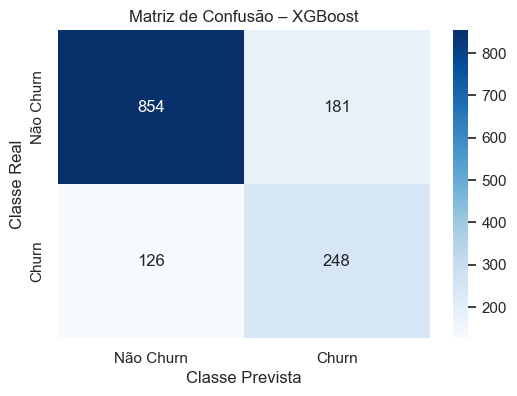


==================== Resultados: XGBoost ====================
  Accuracy    : 0.7821
  Precision   : 0.5781
  Recall      : 0.6631
  F1          : 0.6177
  AUC-ROC     : 0.8542
  AUC-PR      : 0.6612
  MCC         : 0.4685
MELHORES HIPERPARÂMETROS COMPLETOS - XGBoost
         Hiperparâmetro           Valor
             base_score             0.5
                booster            None
              callbacks            None
      colsample_bylevel            None
       colsample_bynode            None
       colsample_bytree            None
                 device            None
  early_stopping_rounds            None
     enable_categorical           False
            eval_metric         logloss
          feature_types            None
                  gamma            None
            grow_policy            None
        importance_type            None
interaction_constraints            None
          learning_rate             0.1
                max_bin            None
      max_c

In [13]:
# [FUNÇÃO TÉCNICA] - Importa XGBoost.
import xgboost as xgb

# [FUNÇÃO TÉCNICA] - Instancia XGBClassifier.
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    base_score=0.5 # Definir base_score explicitamente como float
)

# [FUNÇÃO TÉCNICA] - Define grade de parâmetros para XGBoost.
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# [FUNÇÃO TÉCNICA] - Imprime mensagem de treinamento.
print("Treinando XGBoost... (Isso pode levar alguns minutos)")

# [FUNÇÃO TÉCNICA] - Chama função de avaliação.
best_xgb, met_xgb = avalia_modelo(
    'XGBoost',
    xgb_clf,
    param_xgb,
    X_train_enc, y_train,   # <--- Use os dados originais codificados
    X_test_enc, y_test,     # <--- Dados de teste
    scoring='f1'
)

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Imprime título.
print("MELHORES HIPERPARÂMETROS COMPLETOS - XGBoost")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Extrai parâmetros do modelo.
params_completos = best_xgb.named_steps['model'].get_params()

# [FUNÇÃO TÉCNICA] - Cria DataFrame com parâmetros.
df_params = pd.DataFrame(list(params_completos.items()),
                        columns=['Hiperparâmetro', 'Valor']).sort_values('Hiperparâmetro')

# [FUNÇÃO TÉCNICA] - Configura opções de exibição.
pd.set_option('display.max_colwidth', None)

# [FUNÇÃO TÉCNICA] - Configura largura.
pd.set_option('display.width', 1000)

# [FUNÇÃO TÉCNICA] - Imprime DataFrame.
print(df_params.to_string(index=False))

# [FUNÇÃO TÉCNICA] - Reseta opção de colwidth.
pd.reset_option('display.max_colwidth')

# [FUNÇÃO TÉCNICA] - Reseta opção de largura.
pd.reset_option('display.width')

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Imprime mensagem de sucesso.
print("\n✓ XGBoost treinado com sucesso!")

## 14 – LightGBM


O terceiro modelo é o LightGBM, um algoritmo de boosting eficiente para grandes conjuntos de dados. O processo de busca varia o número de estimadores, a profundidade máxima das árvores, a taxa de aprendizado e os parâmetros de amostragem de instâncias e atributos. Assim como nos modelos anteriores, a otimização é conduzida sobre o conjunto de treino balanceado por SMOTE e a versão codificada das variáveis preditoras, com validação cruzada estratificada em 5 folds, e o desempenho final é avaliado no conjunto de teste independente por meio das métricas de acurácia, precisão, recall, F1‑Score, AUC‑ROC, AUC‑PR e MCC



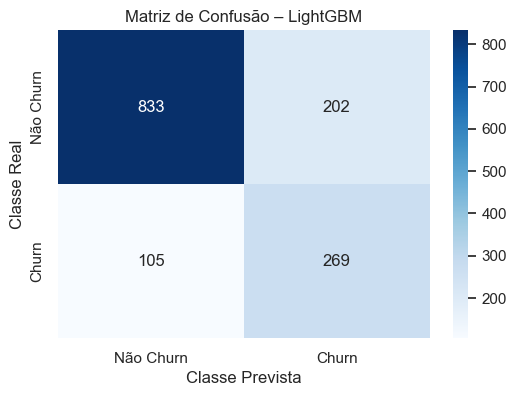


==================== Resultados: LightGBM ====================
  Accuracy    : 0.7821
  Precision   : 0.5711
  Recall      : 0.7193
  F1          : 0.6367
  AUC-ROC     : 0.8548
  AUC-PR      : 0.6645
  MCC         : 0.4906
MELHORES HIPERPARÂMETROS COMPLETOS - LightGBM
   Hiperparâmetro  Valor
    boosting_type   gbdt
     class_weight   None
 colsample_bytree    0.8
  importance_type  split
    learning_rate   0.05
        max_depth      4
min_child_samples     20
 min_child_weight  0.001
   min_split_gain    0.0
     n_estimators    100
           n_jobs     -1
       num_leaves     31
        objective   None
     random_state     42
        reg_alpha    0.0
       reg_lambda    0.0
        subsample    0.8
subsample_for_bin 200000
   subsample_freq      0
          verbose     -1


In [14]:
# [FUNÇÃO TÉCNICA] - Instancia LGBMClassifier.
gb_clf = lgb.LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# [FUNÇÃO TÉCNICA] - Define grade de parâmetros para LightGBM.
param_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# [FUNÇÃO TÉCNICA] - Chama função de avaliação.
best_lgb, met_lgb = avalia_modelo(
    'LightGBM', gb_clf, param_lgb,
    X_train_enc, y_train,   # <--- CORRIGIDO
    X_test_enc, y_test,
    scoring='f1'
)

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Imprime título.
print("MELHORES HIPERPARÂMETROS COMPLETOS - LightGBM")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Extrai parâmetros do modelo.
params_completos = best_lgb.named_steps['model'].get_params()

# [FUNÇÃO TÉCNICA] - Cria DataFrame com parâmetros.
df_params = pd.DataFrame(list(params_completos.items()),
                        columns=['Hiperparâmetro', 'Valor']).sort_values('Hiperparâmetro')

# [FUNÇÃO TÉCNICA] - Configura opções de exibição.
pd.set_option('display.max_colwidth', None)

# [FUNÇÃO TÉCNICA] - Configura largura.
pd.set_option('display.width', 1000)

# [FUNÇÃO TÉCNICA] - Imprime DataFrame.
print(df_params.to_string(index=False))

# [FUNÇÃO TÉCNICA] - Reseta opção de colwidth.
pd.reset_option('display.max_colwidth')

# [FUNÇÃO TÉCNICA] - Reseta opção de largura.
pd.reset_option('display.width')

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

## 15 – CatBoost

Por fim, é realizado o ajuste do CatBoost, modelo de boosting particularmente adequado para dados tabulares. O grid de busca considera número de iterações, profundidade das árvores, taxa de aprendizado e regularização L2. Embora o CatBoost possua mecanismos internos para lidar com variáveis categóricas, neste estudo ele é aplicado sobre o conjunto de treino balanceado por SMOTE e a versão codificada das variáveis preditoras, garantindo comparabilidade com os demais modelos. A otimização é conduzida com validação cruzada estratificada em 5 folds, e o desempenho final é avaliado no conjunto de teste independente pelas métricas de acurácia, precisão, recall, F1‑Score, AUC‑ROC, AUC‑PR e MCC.

Treinando CatBoost... Isso pode levar alguns minutos


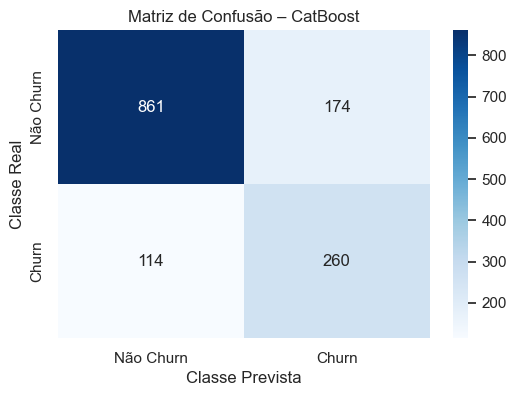


==================== Resultados: CatBoost ====================
  Accuracy    : 0.7956
  Precision   : 0.5991
  Recall      : 0.6952
  F1          : 0.6436
  AUC-ROC     : 0.8536
  AUC-PR      : 0.6725
  MCC         : 0.5041
CatBoost treinado com sucesso!
MELHORES HIPERPARÂMETROS COMPLETOS - CatBoost
                   Hiperparâmetro                       Valor
               auto_class_weights                        None
              bayesian_matrix_reg                         0.1
             best_model_min_trees                           1
               boost_from_average                       False
                    boosting_type                       Plain
                   bootstrap_type                         MVS
                     border_count                         254
                      class_names                      [0, 1]
                    classes_count                           0
                            depth                           4
                

In [15]:
# [FUNÇÃO TÉCNICA] - Importa CatBoostClassifier.
from catboost import CatBoostClassifier

# [FUNÇÃO TÉCNICA] - Instancia CatBoostClassifier.
cat_clf = CatBoostClassifier(
    random_state=42,
    verbose=False
)

# [FUNÇÃO TÉCNICA] - Define grade de parâmetros para CatBoost.
param_cat = {
    'iterations': [200],
    'depth': [4, 6,],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3]
    
}

# [FUNÇÃO TÉCNICA] - Imprime mensagem de treinamento.
print("Treinando CatBoost... Isso pode levar alguns minutos")

# [FUNÇÃO TÉCNICA] - Chama função de avaliação.
best_cat, met_cat = avalia_modelo(
    "CatBoost", cat_clf, param_cat,
    X_train_enc, y_train,
    X_test_enc, y_test,
    scoring='f1'
)

# [FUNÇÃO TÉCNICA] - Imprime mensagem de sucesso.
print("CatBoost treinado com sucesso!")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Imprime título.
print("MELHORES HIPERPARÂMETROS COMPLETOS - CatBoost")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

# [FUNÇÃO TÉCNICA] - Extrai parâmetros do modelo CatBoost.
params_completos = best_cat.named_steps['model'].get_all_params()

# [FUNÇÃO TÉCNICA] - Cria DataFrame com parâmetros.
df_params = pd.DataFrame(list(params_completos.items()),
                        columns=['Hiperparâmetro', 'Valor']).sort_values('Hiperparâmetro')

# [FUNÇÃO TÉCNICA] - Configura opções de exibição.
pd.set_option('display.max_colwidth', None)

# [FUNÇÃO TÉCNICA] - Configura largura.
pd.set_option('display.width', 1000)

# [FUNÇÃO TÉCNICA] - Imprime DataFrame.
print(df_params.to_string(index=False))

# [FUNÇÃO TÉCNICA] - Reseta opção de colwidth.
pd.reset_option('display.max_colwidth')

# [FUNÇÃO TÉCNICA] - Reseta opção de largura.
pd.reset_option('display.width')

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*80)

## 16 – Consolidação com Validação Cruzada

Com os cinco modelos treinados e otimizados, realiza-se uma validação cruzada estratificada com 5 folds para consolidar as métricas de desempenho. Essa abordagem fornece estimativas mais robustas e confiáveis do desempenho real de cada algoritmo, eliminando a dependência de um único conjunto de teste e garantindo a confiabilidade dos resultados para a dissertação.

A tabela reúne, para cada modelo, os valores de acurácia, precisão, recall, F1‑Score,
AUC‑ROC, AUC‑PR e MCC, facilitando a identificação do algoritmo mais adequado para
o problema de predição de churn. A **Regressão Logística** serve como baseline
interpretável, enquanto os modelos de ensemble e boosting representam abordagens
mais sofisticadas.


In [16]:
# [FUNÇÃO TÉCNICA] - Importa métricas e funções necessárias.
from sklearn.metrics import matthews_corrcoef, make_scorer

# [FUNÇÃO TÉCNICA] - Importa NumPy.
import numpy as np

# [FUNÇÃO TÉCNICA] - Prepara dados finais limpando infinitos e NaNs.
X_final = X.copy()

# [FUNÇÃO TÉCNICA] - Substitui infinitos por nulos.
X_final = X_final.replace([np.inf, -np.inf], np.nan).fillna(0)

# [FUNÇÃO TÉCNICA] - Copia a variável alvo.
y_final = y.copy()

# [FUNÇÃO TÉCNICA] - Define dicionário de métricas.
metricas_alvo = {
    'acc': 'accuracy',
    'prec': 'precision',
    'rec': 'recall',
    'f1': 'f1',
    'auc_roc': 'roc_auc',
    'auc_pr': 'average_precision',
    'mcc': make_scorer(matthews_corrcoef)
}

# [FUNÇÃO TÉCNICA] - Define dicionário de modelos.
modelos_comp = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbosity=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# [FUNÇÃO TÉCNICA] - Inicializa dicionário de métricas consolidadas.
metricas_consolidadas = {}

# [FUNÇÃO TÉCNICA] - Imprime mensagem de processamento.
print("⏳ Processando modelos com Validação Cruzada Estratificada...")

# [FUNÇÃO TÉCNICA] - Inicia loop sobre todos os modelos.
for nome, algoritmo in modelos_comp.items():
    
    # [FUNÇÃO TÉCNICA] - Cria pipeline para cada algoritmo.
    pipe = criar_pipeline(algoritmo)
    
    # [FUNÇÃO TÉCNICA] - Executa validação cruzada.
    res = cross_validate(pipe, X_final, y_final, cv=cv_estratificado, scoring=metricas_alvo)
    
    # [FUNÇÃO TÉCNICA] - Salva médias das métricas.
    metricas_consolidadas[nome] = {
        'Modelo': nome,
        'Accuracy': res['test_acc'].mean(),
        'Precision': res['test_prec'].mean(),
        'Recall': res['test_rec'].mean(),
        'F1': res['test_f1'].mean(),
        'AUC-ROC': res['test_auc_roc'].mean(),
        'AUC-PR': res['test_auc_pr'].mean(),
        'MCC': res['test_mcc'].mean()
    }

    # [FUNÇÃO TÉCNICA] - Imprime confirmação de conclusão.
    print(f"✅ {nome} concluído.")

# [FUNÇÃO TÉCNICA] - Atribui métricas da regressão logística.
met_lr = metricas_consolidadas['LogisticRegression']

# [FUNÇÃO TÉCNICA] - Atribui métricas do Random Forest.
met_rf = metricas_consolidadas['RandomForest']

# [FUNÇÃO TÉCNICA] - Atribui métricas do XGBoost.
met_xgb = metricas_consolidadas['XGBoost']

# [FUNÇÃO TÉCNICA] - Atribui métricas do LightGBM.
met_lgb = metricas_consolidadas['LightGBM']

# [FUNÇÃO TÉCNICA] - Atribui métricas do CatBoost.
met_cat = metricas_consolidadas['CatBoost']

# [FUNÇÃO TÉCNICA] - Imprime mensagem final.
print("\n🚀 Todos os dados estão prontos para a tabela comparativa!")

⏳ Processando modelos com Validação Cruzada Estratificada...
✅ LogisticRegression concluído.
✅ RandomForest concluído.
✅ XGBoost concluído.
✅ LightGBM concluído.
✅ CatBoost concluído.

🚀 Todos os dados estão prontos para a tabela comparativa!


In [17]:
# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Cria DataFrame com resultados.
results_tunados = pd.DataFrame([met_lr, met_rf, met_xgb, met_lgb, met_cat])

# [FUNÇÃO TÉCNICA] - Arredonda valores para 3 casas decimais.
results_tunados = results_tunados.round(3)

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("\n" + "="*90)

# [FUNÇÃO TÉCNICA] - Imprime título da tabela.
print("TABELA 2: COMPARAÇÃO DE DESEMPENHO DOS ALGORITMOS (VALIDAÇÃO CRUZADA)")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*90)

# [FUNÇÃO TÉCNICA] - Imprime tabela em formato markdown.
print(results_tunados.to_markdown(index=False))

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*90)

# [FUNÇÃO TÉCNICA] - Define lista de métricas.
metricas_corretas = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'AUC-PR']

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("\n" + "="*90)

# [FUNÇÃO TÉCNICA] - Imprime título da seção.
print("MELHORES RESULTADOS POR INDICADOR")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*90)

# [FUNÇÃO TÉCNICA] - Inicia loop sobre métri cas.
for metrica in metricas_corretas:
    
    # [FUNÇÃO TÉCNICA] - Encontra índice do melhor valor.
    melhor_idx = results_tunados[metrica].idxmax()
    
    # [FUNÇÃO TÉCNICA] - Imprime resultado da métrica.
    print(f"{metrica:<12} → {results_tunados.loc[melhor_idx, 'Modelo']:<20} ({results_tunados.loc[melhor_idx, metrica]:.3f})")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("\n" + "="*90)

# [FUNÇÃO TÉCNICA] - Imprime título da análise.
print("ANÁLISE DE GANHO SOBRE O BASELINE (F1-SCORE)")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*90)

# [FUNÇÃO TÉCNICA] - Extrai F1 da regressão logística.
baseline_f1 = results_tunados.loc[results_tunados['Modelo'] == 'LogisticRegression', 'F1'].values[0]

# [FUNÇÃO TÉCNICA] - Inicia loop sobre resultados.
for _, row in results_tunados.iterrows():
    
    # [FUNÇÃO TÉCNICA] - Verifica se não é o baseline.
    if row['Modelo'] != 'LogisticRegression':
        
        # [FUNÇÃO TÉCNICA] - Calcula ganho absoluto.
        ganho_abs = row['F1'] - baseline_f1
        
        # [FUNÇÃO TÉCNICA] - Calcula ganho percentual.
        ganho_perc = (ganho_abs / baseline_f1) * 100
        
        # [FUNÇÃO TÉCNICA] - Imprime resultado do ganho.
        print(f"{row['Modelo']:<20} → Ganho F1: {ganho_abs:+.3f} ({ganho_perc:+.1f}%)")

# [FUNÇÃO TÉCNICA] - Imprime separador final.
print("="*90)


TABELA 2: COMPARAÇÃO DE DESEMPENHO DOS ALGORITMOS (VALIDAÇÃO CRUZADA)
| Modelo             |   Accuracy |   Precision |   Recall |    F1 |   AUC-ROC |   AUC-PR |   MCC |
|:-------------------|-----------:|------------:|---------:|------:|----------:|---------:|------:|
| LogisticRegression |      0.762 |       0.535 |    0.806 | 0.643 |     0.858 |    0.675 | 0.498 |
| RandomForest       |      0.786 |       0.596 |    0.603 | 0.599 |     0.838 |    0.628 | 0.453 |
| XGBoost            |      0.784 |       0.594 |    0.592 | 0.593 |     0.838 |    0.639 | 0.446 |
| LightGBM           |      0.796 |       0.613 |    0.629 | 0.621 |     0.853 |    0.665 | 0.481 |
| CatBoost           |      0.797 |       0.616 |    0.625 | 0.621 |     0.856 |    0.674 | 0.482 |

MELHORES RESULTADOS POR INDICADOR
Accuracy     → CatBoost             (0.797)
Precision    → CatBoost             (0.616)
Recall       → LogisticRegression   (0.806)
F1           → LogisticRegression   (0.643)
AUC-ROC      → Log

## 17 – Gráfico de F1-Score por Modelo

Para facilitar a visualização das diferenças de desempenho, foi construído um gráfico
de barras com o F1‑Score de cada modelo, evidenciando quais algoritmos se destacam
após o balanceamento por SMOTE e a otimização de hiperparâmetros.

O gráfico permite identificar rapidamente:
1. O **ganho** dos modelos complexos sobre o baseline (Regressão Logística)
2. A **similaridade** de desempenho entre os diferentes algoritmos de boosting
3. Se o **aumento de complexidade** justifica o ganho em performance

Esta visualização auxilia na tomada de decisão sobre qual modelo implementar em
produção, considerando o trade-off entre performance e interpretabilidade/simplicidade.

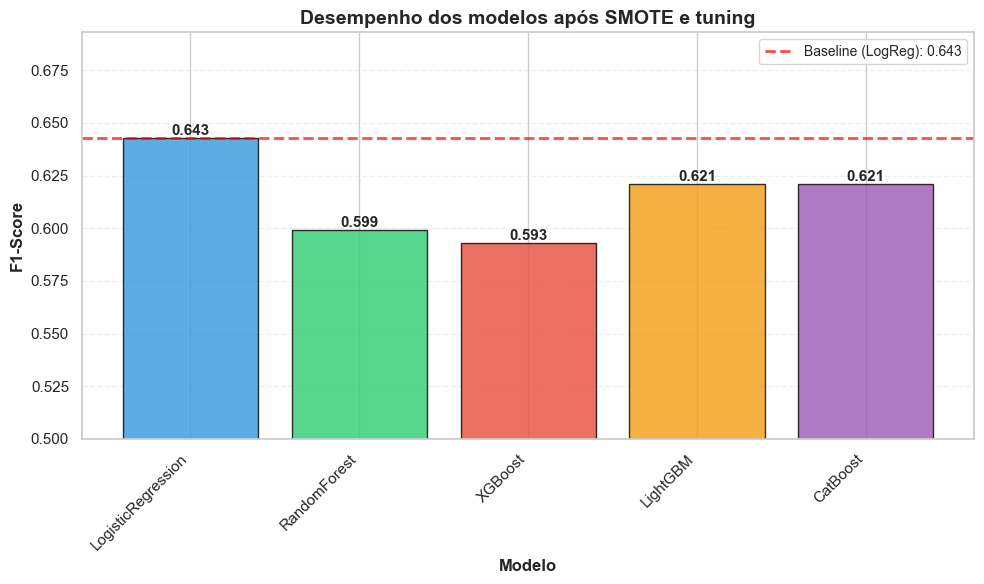

In [18]:
# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(10, 6))

# [FUNÇÃO TÉCNICA] - Define cores para os modelos.
cores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']  # Cores diferentes para cada modelo

# [FUNÇÃO TÉCNICA] - Cria gráfico de barras.
barras = plt.bar(results_tunados['Modelo'], results_tunados['F1'], color=cores, alpha=0.8, edgecolor='black')

# [FUNÇÃO TÉCNICA] - Inicia loop sobre as barras.
for barra in barras:
    
    # [FUNÇÃO TÉCNICA] - Obtém altura da barra.
    altura = barra.get_height()
    
    # [FUNÇÃO TÉCNICA] - Adiciona texto no topo da barra.
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Calcula baseline.
baseline_f1 = results_tunados.loc[results_tunados['Modelo'] == 'LogisticRegression', 'F1'].values[0]

# [FUNÇÃO TÉCNICA] - Adiciona linha horizontal do baseline.
plt.axhline(y=baseline_f1, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Baseline (LogReg): {baseline_f1:.3f}')

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo Y.
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo X.
plt.xlabel('Modelo', fontsize=12, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title('Desempenho dos modelos após SMOTE e tuning', fontsize=14, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Define limites do eixo Y dinamicamente.
plt.ylim(0.50, results_tunados['F1'].max() + 0.05)  # Ajustar escala dinamicamente

# [FUNÇÃO TÉCNICA] - Rotaciona rótulos do eixo X.
plt.xticks(rotation=45, ha='right')

# [FUNÇÃO TÉCNICA] - Adiciona legenda.
plt.legend(fontsize=10)

# [FUNÇÃO TÉCNICA] - Adiciona grade no eixo Y.
plt.grid(axis='y', alpha=0.3, linestyle='--')

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

## 18 – SHAP para Regressão Logística

A partir do modelo Regressão Logística selecionado como melhor desempenho após o balanceamento e a otimização de hiperparâmetros, aplica‑se a técnica SHAP (SHapley Additive exPlanations) para estimar a importância global das variáveis. São calculados os valores SHAP no conjunto de teste independente, utilizando a versão codificada das variáveis preditoras, e em seguida obtida a importância média absoluta de cada atributo, resultando em um ranking das variáveis mais relevantes para a predição de churn.

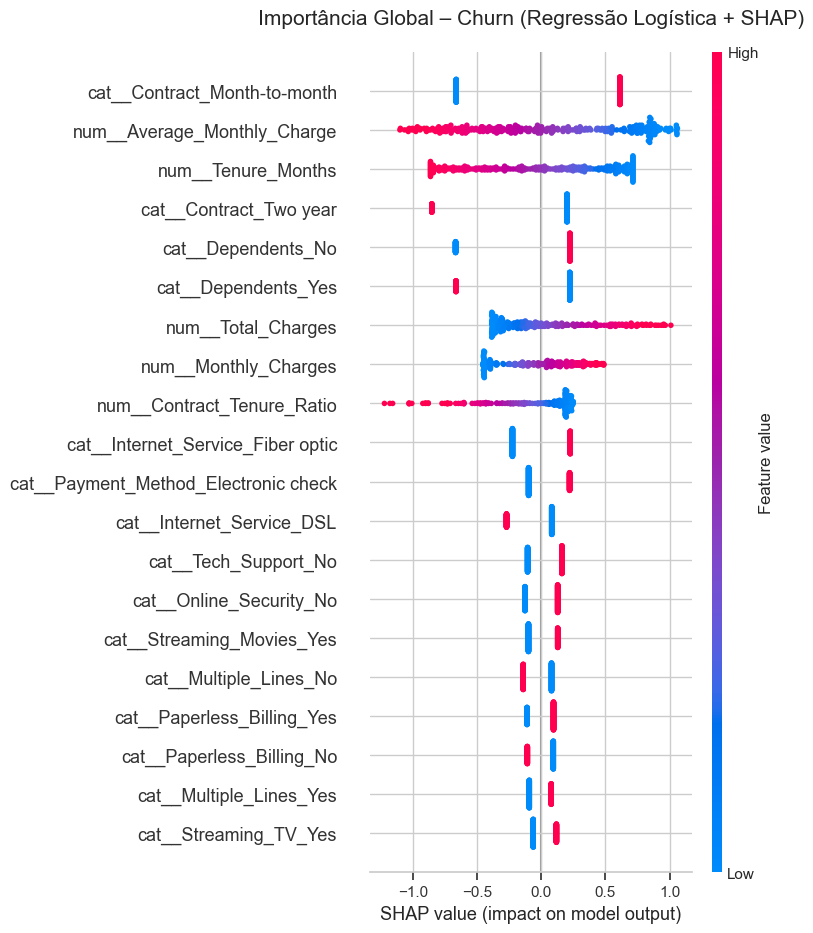

In [19]:
# [FUNÇÃO TÉCNICA] - Importa SHAP.
import shap

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Prepara nomes das colunas codificadas.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Cria DataFrame de teste codificado.
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

# [FUNÇÃO TÉCNICA] - Cria amostra do conjunto de teste.
X_sample = X_test_df.sample(300, random_state=42)

# [FUNÇÃO TÉCNICA] - Extrai modelo Regressão Logística do pipeline.
lr_model = best_lr.named_steps['model']

# [FUNÇÃO TÉCNICA] - Cria explainer SHAP para Regressão Logística.
explainer_lr = shap.LinearExplainer(lr_model, X_train_enc) 

# [FUNÇÃO TÉCNICA] - Calcula valores SHAP.
shap_lr = explainer_lr.shap_values(X_sample)

# [FUNÇÃO TÉCNICA] - Ajusta valores SHAP para é classe positiva.
shap_lr_plot = shap_lr[1] if isinstance(shap_lr, list) else shap_lr

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 8))

# [FUNÇÃO TÉCNICA] - Plota gráfico de resumo SHAP.
shap.summary_plot(shap_lr_plot, X_sample, show=False)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title("Importância Global – Churn (Regressão Logística + SHAP)", fontsize=15, pad=20)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()


## 19 – SHAP para Random Forest


Calculando SHAP – Random Forest... (aguarde)


<Figure size 1200x800 with 0 Axes>

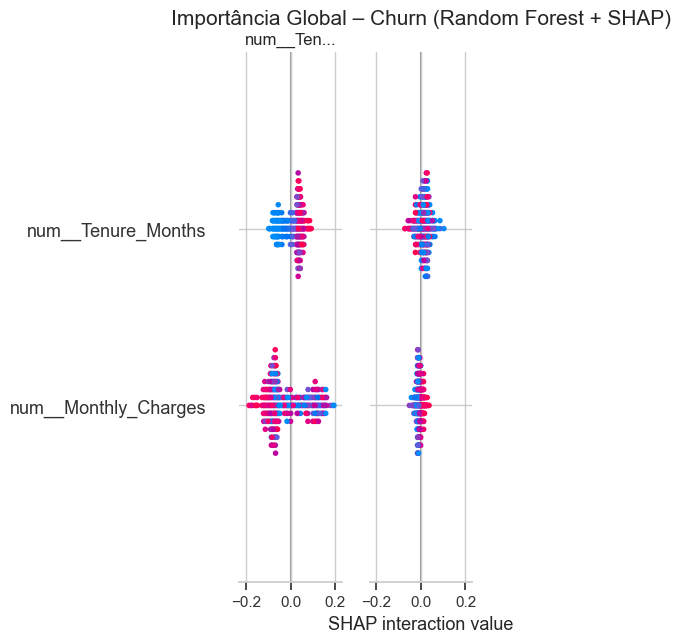

In [20]:
# [FUNÇÃO TÉCNICA] - Importa SHAP.
import shap

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Prepara nomes das colunas codificadas.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Cria DataFrame de teste codificado.
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

# [FUNÇÃO TÉCNICA] - Cria amostra do conjunto de teste.
X_sample = X_test_df.sample(300, random_state=42)

# [FUNÇÃO TÉCNICA] - Extrai modelo Random Forest do pipeline.
rf_model = best_rf.named_steps['model']

# [FUNÇÃO TÉCNICA] - Imprime mensagem de processamento.
print("Calculando SHAP – Random Forest... (aguarde)")

# [FUNÇÃO TÉCNICA] - Cria explainer SHAP para Random Forest.
explainer_rf = shap.TreeExplainer(rf_model)

# [FUNÇÃO TÉCNICA] - Calcula valores SHAP.
shap_rf = explainer_rf.shap_values(X_sample)

# [FUNÇÃO TÉCNICA] - Ajusta valores SHAP para classe positiva.
shap_rf_plot = shap_rf[1] if isinstance(shap_rf, list) else shap_rf

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 8))

# [FUNÇÃO TÉCNICA] - Plota gráfico de resumo SHAP.
shap.summary_plot(shap_rf_plot, X_sample, show=False)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title("Importância Global – Churn (Random Forest + SHAP)", fontsize=15, pad=20)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

## 20 – SHAP para XGBoost

Calculando SHAP – XGBoost... (aguarde)


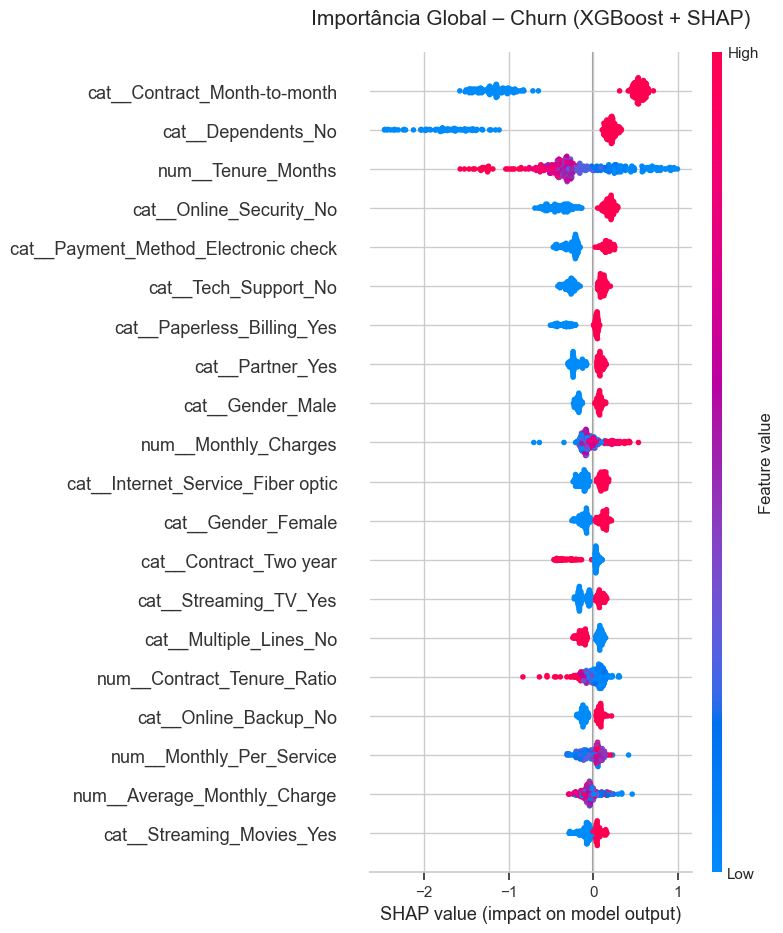

In [21]:
# [FUNÇÃO TÉCNICA] - Importa SHAP.
import shap

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Prepara nomes das colunas codificadas.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Cria DataFrame de teste codificado.
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

# [FUNÇÃO TÉCNICA] - Cria amostra do conjunto de teste.
X_sample = X_test_df.sample(300, random_state=42)

# [FUNÇÃO TÉCNICA] - Extrai modelo XGBoost do pipeline.
xgb_model = best_xgb.named_steps['model']

# [FUNÇÃO TÉCNICA] - Imprime mensagem de processamento.
print("Calculando SHAP – XGBoost... (aguarde)")

# [FUNÇÃO TÉCNICA] - Cria explainer SHAP para XGBoost.
explainer_xgb = shap.TreeExplainer(xgb_model)

# [FUNÇÃO TÉCNICA] - Calcula valores SHAP.
shap_xgb = explainer_xgb.shap_values(X_sample)

# [FUNÇÃO TÉCNICA] - Ajusta valores SHAP para classe positiva.
shap_xgb_plot = shap_xgb[1] if isinstance(shap_xgb, list) else shap_xgb

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 8))

# [FUNÇÃO TÉCNICA] - Plota gráfico de resumo SHAP.
shap.summary_plot(shap_xgb_plot, X_sample, show=False)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title("Importância Global – Churn (XGBoost + SHAP)", fontsize=15, pad=20)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

## 21 – SHAP para CatBoost

Calculando SHAP – CatBoost... (aguarde)


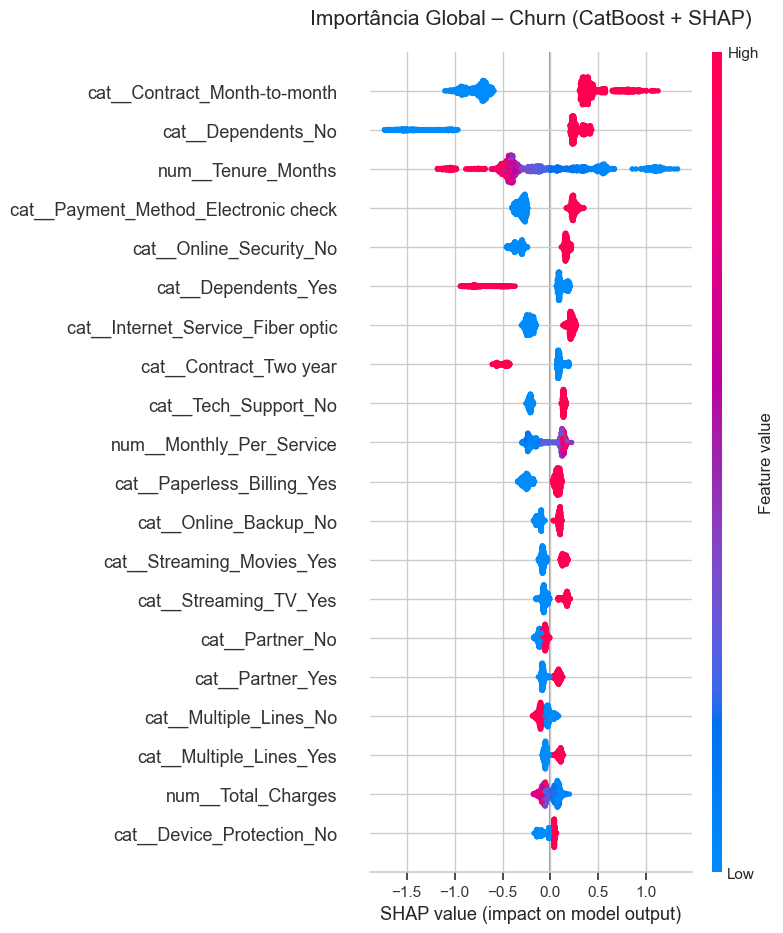

In [22]:
# [FUNÇÃO TÉCNICA] - Importa SHAP.
import shap

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Prepara nomes das colunas.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Cria DataFrame de teste.
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

# [FUNÇÃO TÉCNICA] - Extrai modelo CatBoost do pipeline.
catboost_model = best_cat.named_steps['model']   # ajuste 'model' se necessário

# [FUNÇÃO TÉCNICA] - Imprime mensagem de processamento.
print("Calculando SHAP – CatBoost... (aguarde)")

# [FUNÇÃO TÉCNICA] - Cria explainer SHAP para CatBoost.
explainer_catboost = shap.TreeExplainer(catboost_model)

# [FUNÇÃO TÉCNICA] - Calcula valores SHAP.
shap_catboost = explainer_catboost.shap_values(X_test_df)

# [FUNÇÃO TÉCNICA] - Ajusta valores SHAP para classe positiva.
shap_catboost_plot = shap_catboost[1] if isinstance(shap_catboost, list) else shap_catboost

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 8))

# [FUNÇÃO TÉCNICA] - Plota gráfico de resumo SHAP.
shap.summary_plot(shap_catboost_plot, X_test_df, show=False)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title("Importância Global – Churn (CatBoost + SHAP)", fontsize=15, pad=20)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

Gerando gráfico SHAP para Regressão Logística...


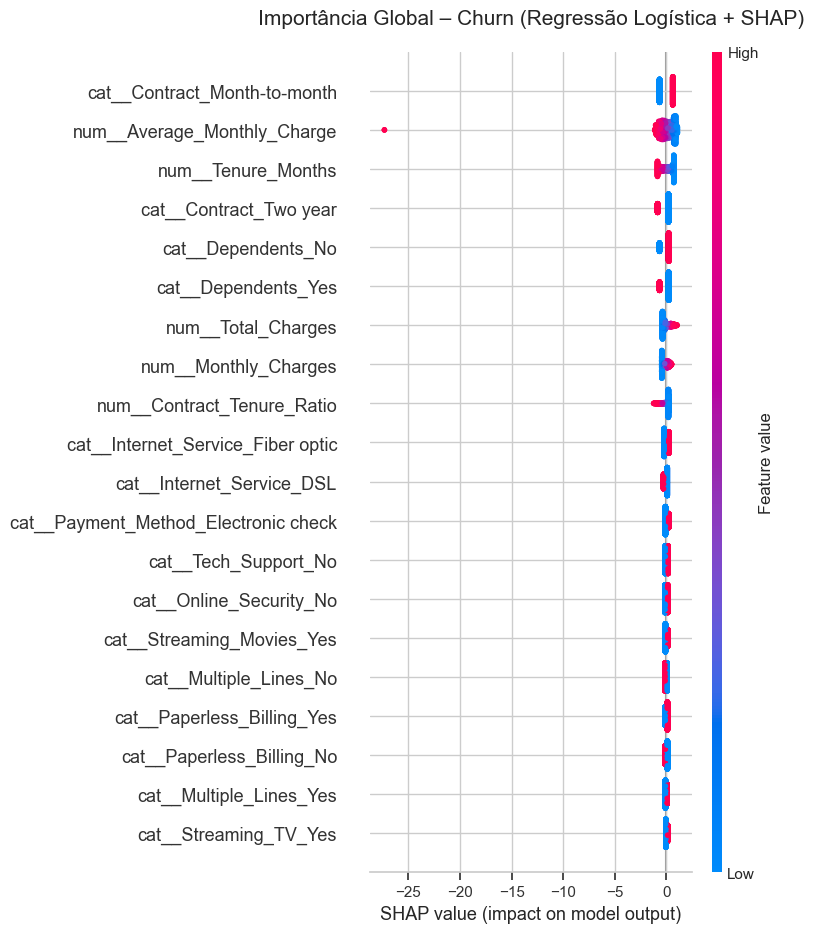

In [23]:
# [FUNÇÃO TÉCNICA] - Extrai modelo Regressão Logística do pipeline.
logistic_model = best_lr.named_steps['model']

# [FUNÇÃO TÉCNICA] - Cria explainer SHAP para modelos lineares.
explainer_lr = shap.LinearExplainer(logistic_model, X_train_enc)

# [FUNÇÃO TÉCNICA] - Calcula valores SHAP no conjunto de teste.
shap_values_lr = explainer_lr.shap_values(X_test_enc)

# [FUNÇÃO TÉCNICA] - Imprime mensagem de geração.
print("Gerando gráfico SHAP para Regressão Logística...")

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 8))

# [FUNÇÃO TÉCNICA] - Plota gráfico de resumo SHAP.
shap.summary_plot(shap_values_lr, X_test_df, show=False)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title("Importância Global – Churn (Regressão Logística + SHAP)", fontsize=15, pad=20)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

## 22 – SHAP para LightGBM

Calculando SHAP – LightGBM... (aguarde)


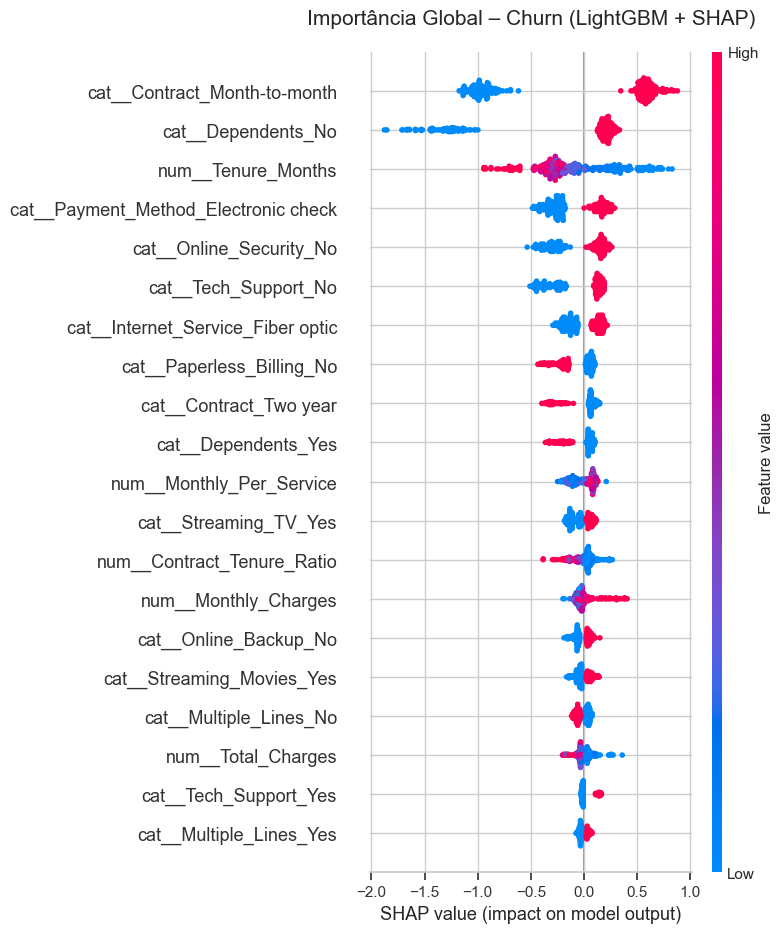

In [24]:
# [FUNÇÃO TÉCNICA] - Importa SHAP.
import shap

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Prepara nomes das colunas.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Cria DataFrame de teste.
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

# [FUNÇÃO TÉCNICA] - Cria amostra do conjunto de teste.
X_sample = X_test_df.sample(300, random_state=42)

# [FUNÇÃO TÉCNICA] - Extrai modelo LightGBM do pipeline.
lgb_model = best_lgb.named_steps['model']

# [FUNÇÃO TÉCNICA] - Imprime mensagem de processamento.
print("Calculando SHAP – LightGBM... (aguarde)")

# [FUNÇÃO TÉCNICA] - Cria explainer SHAP para LightGBM.
explainer_lgb = shap.TreeExplainer(lgb_model)

# [FUNÇÃO TÉCNICA] - Calcula valores SHAP.
shap_lgb = explainer_lgb.shap_values(X_sample)

# [FUNÇÃO TÉCNICA] - Ajusta valores SHAP para classe positiva.
shap_lgb_plot = shap_lgb[1] if isinstance(shap_lgb, list) else shap_lgb

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 8))

# [FUNÇÃO TÉCNICA] - Plota gráfico de resumo SHAP.
shap.summary_plot(shap_lgb_plot, X_sample, show=False)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title("Importância Global – Churn (LightGBM + SHAP)", fontsize=15, pad=20)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

## 23 – SHAP Global - Top 10 Features

Ranking das 10 variáveis de maior importância segundo análise SHAP, com visualização em gráfico de barras horizontais para facilitar interpretação dos fatores mais relevantes na predição de churn.



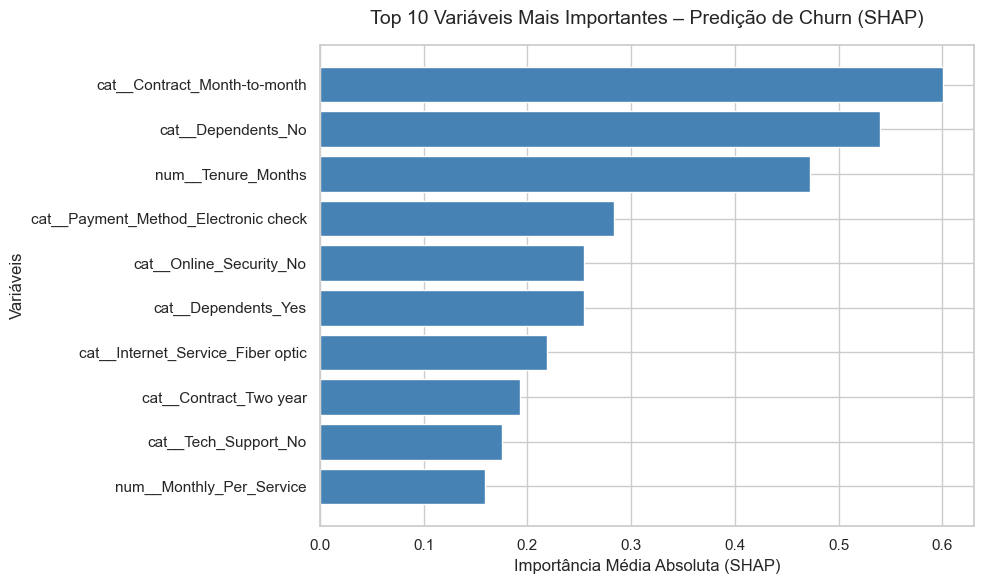


Top 10 Variáveis Mais Importantes:
                             Feature  Importância
        cat__Contract_Month-to-month     0.600600
                  cat__Dependents_No     0.539970
                  num__Tenure_Months     0.472422
cat__Payment_Method_Electronic check     0.283399
             cat__Online_Security_No     0.254232
                 cat__Dependents_Yes     0.254194
   cat__Internet_Service_Fiber optic     0.219249
              cat__Contract_Two year     0.193416
                cat__Tech_Support_No     0.175982
            num__Monthly_Per_Service     0.158729


In [35]:
# [FUNÇÃO TÉCNICA] - Importa NumPy.
import numpy as np

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Prepara nomes das colunas.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()

# [FUNÇÃO TÉCNICA] - Cria DataFrame de teste.
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

# [FUNÇÃO TÉCNICA] - Seleciona melhor modelo CatBoost.
cat_model = best_cat.named_steps['model']

# [FUNÇÃO TÉCNICA] - Cria explainer SHAP.
explainer = shap.TreeExplainer(cat_model)

# [FUNÇÃO TÉCNICA] - Calcula valores SHAP.
shap_values = explainer.shap_values(X_test_df)

# [FUNÇÃO TÉCNICA] - Ajusta para classificação binária.
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# [FUNÇÃO TÉCNICA] - Calcula importância média absoluta.
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

# [FUNÇÃO TÉCNICA] - Cria DataFrame com importâncias.
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importância': mean_abs_shap
}).sort_values('Importância', ascending=False)

# [FUNÇÃO TÉCNICA] - Seleciona Top 10.
top10 = importance_df.head(10)

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(10, 6))

# [FUNÇÃO TÉCNICA] - Plota gráfico de barras horizontais.
plt.barh(range(len(top10)), top10['Importância'], color='steelblue')

# [FUNÇÃO TÉCNICA] - Define rótulos no eixo Y.
plt.yticks(range(len(top10)), top10['Feature'])

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo X.
plt.xlabel('Importância Média Absoluta (SHAP)', fontsize=12)

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo Y.
plt.ylabel('Variáveis', fontsize=12)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title('Top 10 Variáveis Mais Importantes – Predição de Churn (SHAP)', fontsize=14, pad=15)

# [FUNÇÃO TÉCNICA] - Inverte eixo Y para maior importância no topo.
plt.gca().invert_yaxis()

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

# [FUNÇÃO TÉCNICA] - Imprime título da tabela.
print("\nTop 10 Variáveis Mais Importantes:")

# [FUNÇÃO TÉCNICA] - Imprime tabela de top10.
print(top10.to_string(index=False))

## 24 – Explicabilidade local com LIME

Enquanto o SHAP fornece uma visão global da importância das variáveis, o LIME é utilizado para explicar decisões individuais do modelo. Nesta etapa, selecionam‑se dois clientes que cancelaram o serviço (churn) e dois que permaneceram (não churn) no conjunto de teste e, com base na versão codificada das variáveis preditoras, são geradas explicações locais indicando quais atributos mais contribuíram para a previsão de cada caso segundo o modelo Catboost otimizado.

In [37]:
# [FUNÇÃO TÉCNICA] - Importa LIME.
import lime

# [FUNÇÃO TÉCNICA] - Importa lime_tabular.
from lime import lime_tabular

# [FUNÇÃO TÉCNICA] - Importa NumPy.
import numpy as np

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Extrai modelo final CatBoost.
modelo_final = best_cat.named_steps['model']

# [FUNÇÃO TÉCNICA] - Obtém nomes das colunas codificadas.
feature_names = feature_names_enc

# [FUNÇÃO TÉCNICA] - Inicializa explainer LIME.
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_enc),
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# [FUNÇÃO TÉCNICA] - Define função wrapper de predição.
def predict_proba_final(data):
    return modelo_final.predict_proba(data)

# [FUNÇÃO TÉCNICA] - Encontra índices de churn no teste.
idx_churn = np.where(y_test == 1)[0][:2]

# [FUNÇÃO TÉCNICA] - Encontra índices de não-churn no teste.
idx_nochurn = np.where(y_test == 0)[0][:2]

# [FUNÇÃO TÉCNICA] - Combina índices de casos de estudo.
indices = list(idx_churn) + list(idx_nochurn)

# [FUNÇÃO TÉCNICA] - Inicializa dicionário de explicações.
explicacoes = {}

# [FUNÇÃO TÉCNICA] - Imprime mensagem de geração.
print("Gerando explicações locais para os casos selecionados...")

# [FUNÇÃO TÉCNICA] - Inicia loop sobre índices.
for i in indices:

    # [FUNÇÃO TÉCNICA] - Extrai dados do cliente no espaço codificado.
    x_row = X_test_enc[i]

    # [FUNÇÃO TÉCNICA] - Gera explicação LIME.
    exp = explainer_lime.explain_instance(
        data_row=x_row,
        predict_fn=predict_proba_final,
        num_features=8
    )

    # [FUNÇÃO TÉCNICA] - Armazena explicação.
    explicacoes[i] = exp

    # [FUNÇÃO TÉCNICA] - Obtém classe real.
    classe_real = y_test.iloc[i]

    # [FUNÇÃO TÉCNICA] - Imprime separador.
    print(f"\n{'='*20} Cliente teste índice {i} (Classe Real: {classe_real}) {'='*20}")

    # [FUNÇÃO TÉCNICA] - Cria DataFrame com explicação.
    df_explicacao = pd.DataFrame(exp.as_list(), columns=['Variável / Regra', 'Impacto Local'])

    # [FUNÇÃO TÉCNICA] - Imprime DataFrame em markdown.
    print(df_explicacao.to_markdown(index=False, floatfmt=".4f"))

Gerando explicações locais para os casos selecionados...

==================== Cliente teste índice 9 (Classe Real: 1) ====================
| Variável / Regra                                    |   Impacto Local |
|:----------------------------------------------------|----------------:|
| 0.00 < cat__Contract_Month-to-month <= 1.00         |          0.2406 |
| cat__Contract_Two year <= 0.00                      |          0.1235 |
| 0.00 < cat__Online_Security_No <= 1.00              |          0.0874 |
| 0.00 < cat__Payment_Method_Electronic check <= 1.00 |          0.0872 |
| cat__Internet_Service_Fiber optic <= 0.00           |         -0.0739 |
| cat__Streaming_Movies_Yes <= 0.00                   |         -0.0682 |
| 0.00 < cat__Online_Backup_No <= 1.00                |          0.0659 |
| cat__Streaming_TV_Yes <= 0.00                       |         -0.0648 |

==================== Cliente teste índice 13 (Classe Real: 1) ====================
| Variável / Regra                  

## 25 – Gráficos LIME (um churn, um não churn)

Para ilustrar graficamente as explicações locais, são apresentados gráficos de barras do LIME para um cliente com churn e um cliente sem churn, destacando as variáveis que mais aumentam ou reduzem a probabilidade prevista de cancelamento.

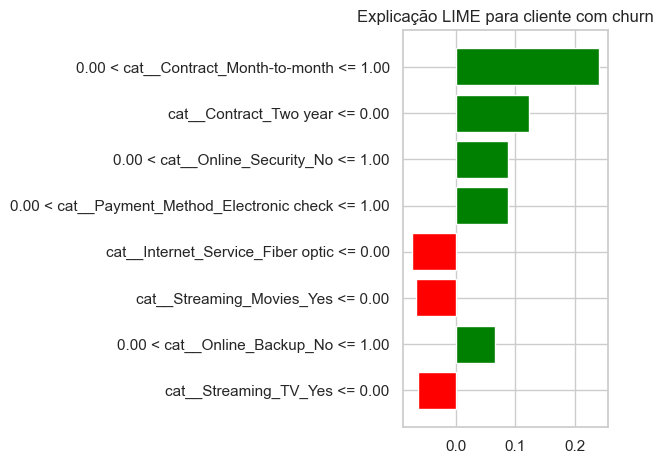

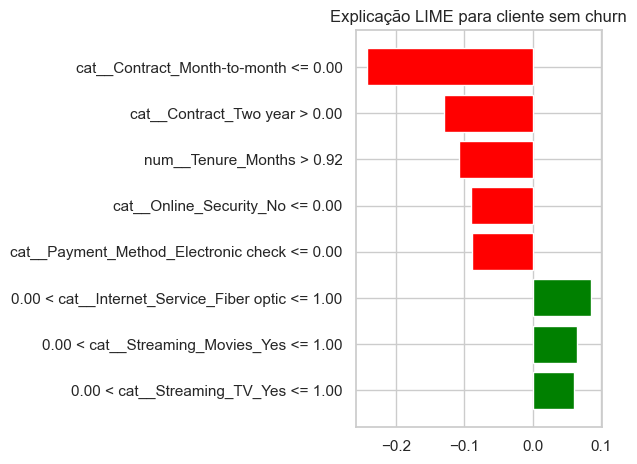

In [38]:
# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Extrai explicação para cliente com churn.
exp_churn = explicacoes[idx_churn[0]]

# [FUNÇÃO TÉCNICA] - Converte explicação para figura pyplot.
fig = exp_churn.as_pyplot_figure()

# [FUNÇÃO TÉCNICA] - Define título da figura.
plt.title('Explicação LIME para cliente com churn')

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

# [FUNÇÃO TÉCNICA] - Extrai explicação para cliente sem churn.
exp_nc = explicacoes[idx_nochurn[0]]

# [FUNÇÃO TÉCNICA] - Converte explicação para figura pyplot.
fig = exp_nc.as_pyplot_figure()

# [FUNÇÃO TÉCNICA] - Define título da figura.
plt.title('Explicação LIME para cliente sem churn')

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

## 26 – Visualização Comparativa de Algoritmos (Radar e Barras)

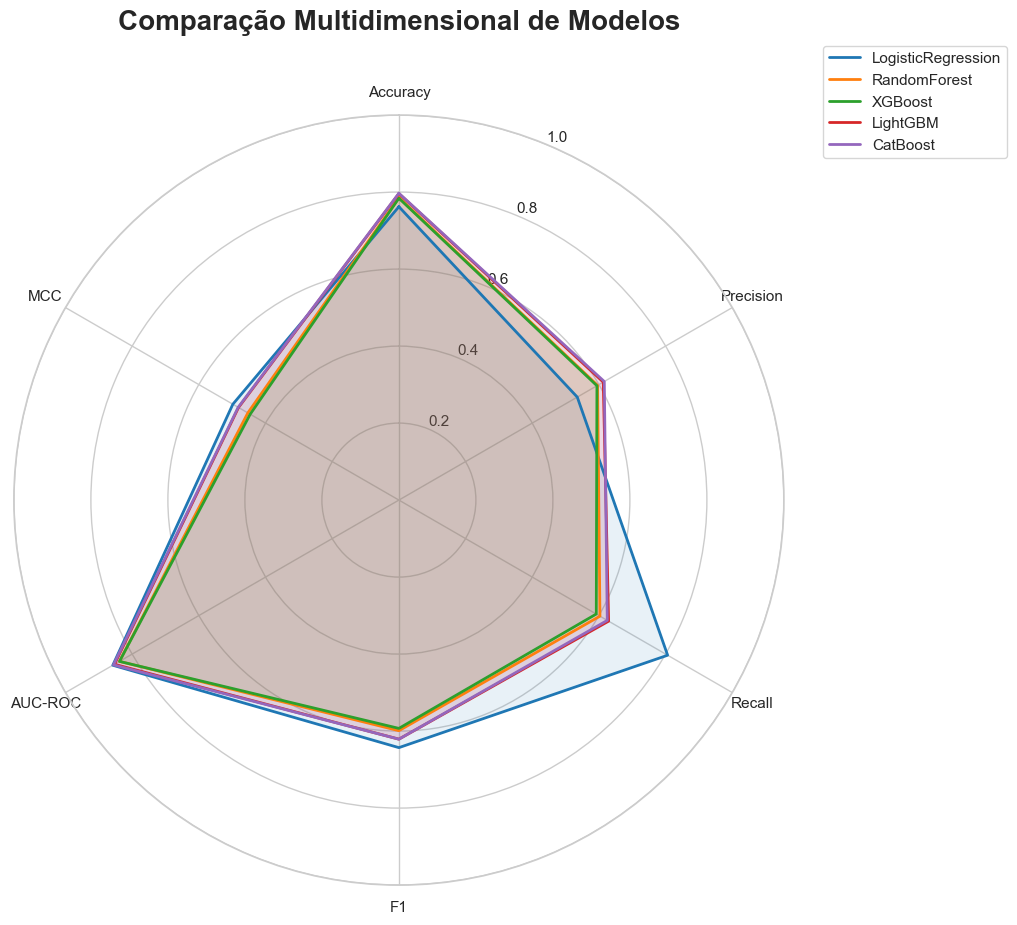

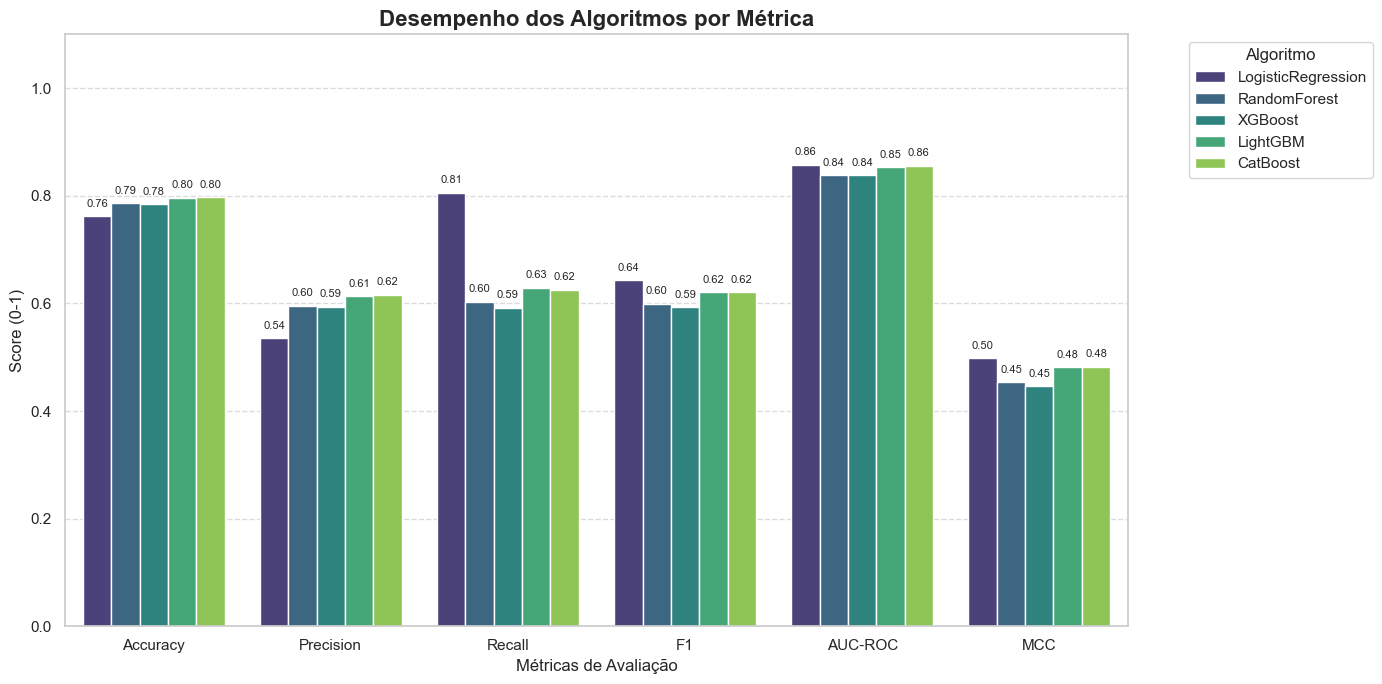

In [28]:
# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Importa NumPy.
import numpy as np

# [FUNÇÃO TÉCNICA] - Importa Seaborn.
import seaborn as sns

# [FUNÇÃO TÉCNICA] - Copia resultados para plotagem.
df_plot = results_tunados.copy()

# [FUNÇÃO TÉCNICA] - Define lista de métricas a comparar.
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'MCC']

# [FUNÇÃO TÉCNICA] - Calcula número de métricas.
num_vars = len(metrics)

# [FUNÇÃO TÉCNICA] - Define ângulos para gráfico de radar.
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()

# [FUNÇÃO TÉCNICA] - Fecha o círculo adicionando primeiro ângulo.
angles += angles[:1] # Fechar o círculo

# [FUNÇÃO TÉCNICA] - Define tamanho da figura com subplot polar.
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# [FUNÇÃO TÉCNICA] - Define cores para cada modelo.
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# [FUNÇÃO TÉCNICA] - Inicia loop sobre modelos.
for i, (idx, row) in enumerate(df_plot.iterrows()):
    
    # [FUNÇÃO TÉCNICA] - Extrai valores das métricas.
    values = row[metrics].values.flatten().tolist()
    
    # [FUNÇÃO TÉCNICA] - Fecha o círculo adicionando primeiro valor.
    values += values[:1] # Fechar o círculo

    # [FUNÇÃO TÉCNICA] - Plota linha do modelo.
    ax.plot(angles, values, color=colors[i], linewidth=2, label=row['Modelo'])
    
    # [FUNÇÃO TÉCNICA] - Preenchimento da área.
    ax.fill(angles, values, color=colors[i], alpha=0.1)

# [FUNÇÃO TÉCNICA] - Ajusta offset dos ângulos.
ax.set_theta_offset(np.pi / 2)

# [FUNÇÃO TÉCNICA] - Ajusta direção dos ângulos.
ax.set_theta_direction(-1)

# [FUNÇÃO TÉCNICA] - Define rótulos das métricas.
ax.set_thetagrids(np.degrees(angles[:-1]), metrics)

# [FUNÇÃO TÉCNICA] - Define escala do eixo Y.
ax.set_ylim(0, 1)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title('Comparação Multidimensional de Modelos', size=20, y=1.1, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Adiciona legenda.
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

# [FUNÇÃO TÉCNICA] - Derrete dados para gráfico de barras.
df_melted = df_plot.melt(id_vars='Modelo', value_vars=metrics, var_name='Métrica', value_name='Valor')

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(14, 7))

# [FUNÇÃO TÉCNICA] - Cria gráfico de barras agrupadas.
sns.barplot(data=df_melted, x='Métrica', y='Valor', hue='Modelo', palette='viridis')

# [FUNÇÃO TÉCNICA] - Define escala do eixo Y.
plt.ylim(0, 1.1)

# [FUNÇÃO TÉCNICA] - Define título do gráfico.
plt.title('Desempenho dos Algoritmos por Métrica', fontsize=16, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo Y.
plt.ylabel('Score (0-1)')

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo X.
plt.xlabel('Métricas de Avaliação')

# [FUNÇÃO TÉCNICA] - Adiciona legenda.
plt.legend(title='Algoritmo', bbox_to_anchor=(1.05, 1), loc='upper left')

# [FUNÇÃO TÉCNICA] - Adiciona grid.
plt.grid(axis='y', linestyle='--', alpha=0.7)

# [FUNÇÃO TÉCNICA] - Inicia loop sobre patches.
for p in plt.gca().patches:
    if p.get_height() > 0:
        # [FUNÇÃO TÉCNICA] - Adiciona anotação sobre cada barra.
        plt.gca().annotate(f'{p.get_height():.2f}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 9),
                           textcoords='offset points',
                           fontsize=8, rotation=0)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

## 27 – Matriz de Decisão Estratégica (Risco vs. Valor)

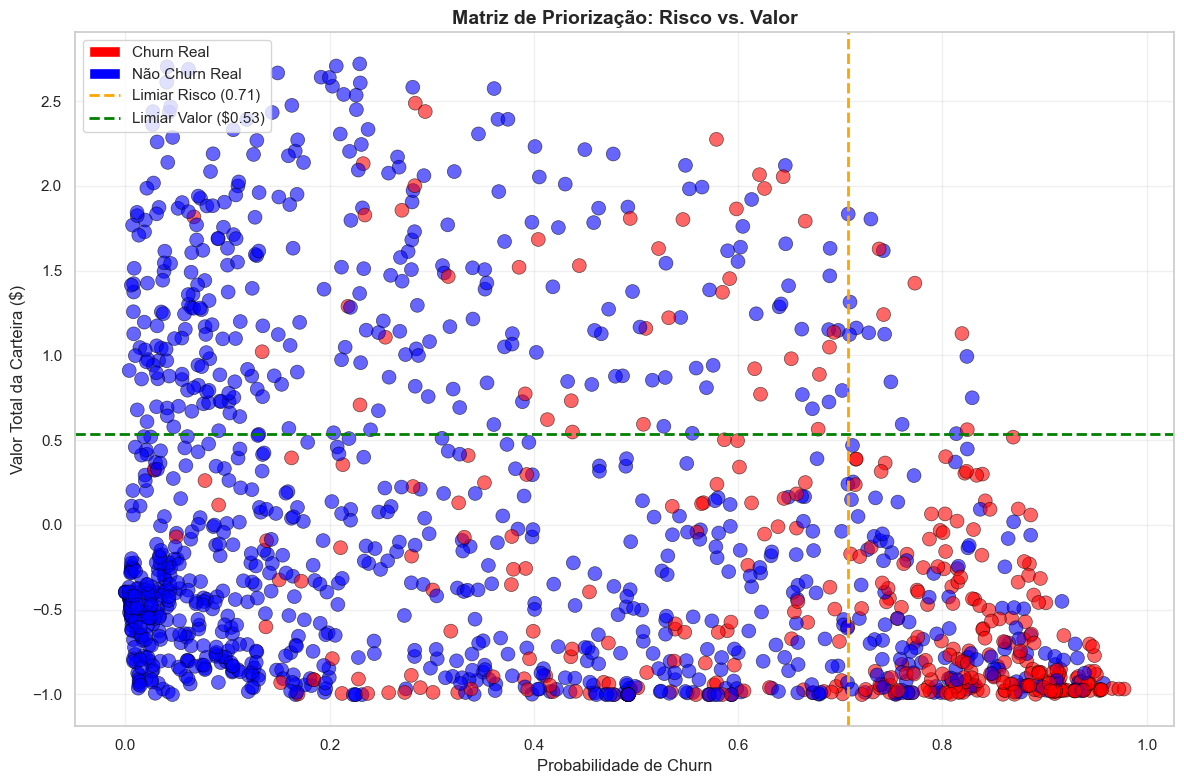

Análise Estratégica:
Alto Risco + Alto Valor: 18 clientes (PRIORIDADE MÁXIMA)
Alto Risco + Baixo Valor: 335 clientes
Baixo Risco + Alto Valor: 335 clientes (Manutenção)


In [29]:
# [FUNÇÃO TÉCNICA] - Importa Matplotlib.
import matplotlib.pyplot as plt

# [FUNÇÃO TÉCNICA] - Importa NumPy.
import numpy as np

# [FUNÇÃO TÉCNICA] - Importa Pandas.
import pandas as pd

# [FUNÇÃO TÉCNICA] - Obtém probabilidades de churn do melhor modelo (Regressão Logística).
x = best_lr.predict_proba(X_test_enc)[:, 1]

# [FUNÇÃO TÉCNICA] - Recupera Total_Charges do conjunto de teste codificado.
feature_names = preprocess_rf_xgb_lgb.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)
y_vals = X_test_df['num__Total_Charges']

# [FUNÇÃO TÉCNICA] - Define tamanho da figura.
plt.figure(figsize=(12, 8))

# [FUNÇÃO TÉCNICA] - Define cores baseadas em churn real.
colors = ['red' if churn == 1 else 'blue' for churn in y_test]

# [FUNÇÃO TÉCNICA] - Cria scatter plot.
plt.scatter(x, y_vals, c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

# [FUNÇÃO TÉCNICA] - Calcula limiar de risco.
limiar_risco = np.quantile(x, 0.75)

# [FUNÇÃO TÉCNICA] - Calcula limiar de valor.
limiar_valor = y_vals.quantile(0.75)

# [FUNÇÃO TÉCNICA] - Adiciona linha vertical de risco.
plt.axvline(limiar_risco, color='orange', linestyle='--', linewidth=2,
            label=f'Limiar Risco ({limiar_risco:.2f})')

# [FUNÇÃO TÉCNICA] - Adiciona linha horizontal de valor.
plt.axhline(limiar_valor, color='green', linestyle='--', linewidth=2,
            label=f'Limiar Valor (${limiar_valor:.2f})')

# [FUNÇÃO TÉCNICA] - Adiciona legenda manual para cores.
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Churn Real'),
    Patch(facecolor='blue', label='Não Churn Real')
]
plt.legend(handles=legend_elements + plt.gca().get_legend_handles_labels()[0],
           loc='upper left')

# [FUNÇÃO TÉCNICA] - Define título.
plt.title('Matriz de Priorização: Risco vs. Valor', fontsize=14, fontweight='bold')

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo X.
plt.xlabel('Probabilidade de Churn')

# [FUNÇÃO TÉCNICA] - Define rótulo do eixo Y.
plt.ylabel('Valor Total da Carteira ($)')

# [FUNÇÃO TÉCNICA] - Adiciona grid.
plt.grid(True, alpha=0.3)

# [FUNÇÃO TÉCNICA] - Ajusta layout.
plt.tight_layout()

# [FUNÇÃO TÉCNICA] - Exibe o gráfico.
plt.show()

# [FUNÇÃO TÉCNICA] - Identifica clientes alto risco, alto valor.
high_risk_high_value = ((x >= limiar_risco) & (y_vals >= limiar_valor)).sum()

# [FUNÇÃO TÉCNICA] - Identifica clientes alto risco, baixo valor.
high_risk_low_value = ((x >= limiar_risco) & (y_vals < limiar_valor)).sum()

# [FUNÇÃO TÉCNICA] - Identifica clientes baixo risco, alto valor.
low_risk_high_value = ((x < limiar_risco) & (y_vals >= limiar_valor)).sum()

# [FUNÇÃO TÉCNICA] - Exibe resumo estratégico.
print("Análise Estratégica:")
print(f"Alto Risco + Alto Valor: {high_risk_high_value} clientes (PRIORIDADE MÁXIMA)")
print(f"Alto Risco + Baixo Valor: {high_risk_low_value} clientes")
print(f"Baixo Risco + Alto Valor: {low_risk_high_value} clientes (Manutenção)")

## 28 – Teste Estatístico de McNemar para Comparação de Modelos

O teste de McNemar é um teste estatístico não-paramétrico utilizado para comparar dois classificadores ou predições emparelhadas. Dados dois modelos A e B fazendo predições no mesmo conjunto de teste, o teste avalia se existe uma diferença estatisticamente significativa no seu desempenho.

**Contingência 2×2 para McNemar:**

|  | B Acerta | B Erra |
|---|---------|--------|
| **A Acerta** | n00 | n01 |
| **A Erra** | n10 | n11 |

- **n01**: Modelo A acerta e Modelo B erra (discordância favorável a A)
- **n10**: Modelo A erra e Modelo B acerta (discordância favorável a B)
- **n00, n11**: Concordâncias (ambos acertam ou ambos erram)

**Hipóteses:**
- H₀: Os dois modelos têm desempenho equivalente (p(n01) = p(n10))
- H₁: Os modelos têm desempenho significativamente diferente

**Estatística do teste:**
Para pequenas amostras, usa-se McNemar Exato (Binomial). Para grandes (n01 + n10 ≥ 25), usa-se aproximação χ²:

$$\chi^2 = \frac{(n_{01} - n_{10})^2}{n_{01} + n_{10}}$$

**Decisão:**
- Se p-valor < α (0.05), rejeita-se H₀ → diferença significativa
- Se p-valor ≥ α, falha-se em rejeitar H₀ → sem diferença significativa


In [30]:
# [FUNÇÃO TÉCNICA] - Importa scipy.stats para testes estatísticos.
from scipy.stats import binomtest, chi2
import numpy as np
import pandas as pd

# [FUNÇÃO TÉCNICA] - Define seed fixa para reprodutibilidade.
np.random.seed(42)

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*100)

# [FUNÇÃO TÉCNICA] - Imprime título da seção.
print("TESTE DE McNEMAR: COMPARAÇÃO ENTRE TRÊS MODELOS FINAIS")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*100)

# [FUNÇÃO TÉCNICA] - Imprime descrição.
print("\nConjunto de teste: hold-out (X_test_enc, y_test)")
print(f"Tamanho da amostra: {len(y_test)} observações")
print(f"Threshold para classificação: 0.5")
print(f"Modelos comparados: Regressão Logística, LightGBM, CatBoost")
print("\n" + "="*100 + "\n")

# [FUNÇÃO TÉCNICA] - Obtém predições probabilísticas do modelo Logistic Regression.
lr_proba = best_lr.predict_proba(X_test_enc)[:, 1]

# [FUNÇÃO TÉCNICA] - Converte probabilidades em classificação binária com threshold 0.5.
lr_pred = (lr_proba >= 0.5).astype(int)

# [FUNÇÃO TÉCNICA] - Obtém predições probabilísticas do modelo LightGBM.
lgb_proba = best_lgb.predict_proba(X_test_enc)[:, 1]

# [FUNÇÃO TÉCNICA] - Converte probabilidades em classificação binária com threshold 0.5.
lgb_pred = (lgb_proba >= 0.5).astype(int)

# [FUNÇÃO TÉCNICA] - Obtém predições probabilísticas do modelo CatBoost.
cat_proba = best_cat.predict_proba(X_test_enc)[:, 1]

# [FUNÇÃO TÉCNICA] - Converte probabilidades em classificação binária com threshold 0.5.
cat_pred = (cat_proba >= 0.5).astype(int)

# [FUNÇÃO TÉCNICA] - Computa acurácia da Regressão Logística.
lr_accuracy = (lr_pred == y_test).sum() / len(y_test)

# [FUNÇÃO TÉCNICA] - Computa acurácia do LightGBM.
lgb_accuracy = (lgb_pred == y_test).sum() / len(y_test)

# [FUNÇÃO TÉCNICA] - Computa acurácia do CatBoost.
cat_accuracy = (cat_pred == y_test).sum() / len(y_test)

# [FUNÇÃO TÉCNICA] - Imprime resumo de acurácias.
print("ACURÁCIA DOS MODELOS NO CONJUNTO DE TESTE (threshold=0.5):")
print(f"  Regressão Logística: {lr_accuracy:.4f}")
print(f"  LightGBM:            {lgb_accuracy:.4f}")
print(f"  CatBoost:            {cat_accuracy:.4f}")
print()


TESTE DE McNEMAR: COMPARAÇÃO ENTRE TRÊS MODELOS FINAIS

Conjunto de teste: hold-out (X_test_enc, y_test)
Tamanho da amostra: 1409 observações
Threshold para classificação: 0.5
Modelos comparados: Regressão Logística, LightGBM, CatBoost


ACURÁCIA DOS MODELOS NO CONJUNTO DE TESTE (threshold=0.5):
  Regressão Logística: 0.7559
  LightGBM:            0.7821
  CatBoost:            0.7956



In [31]:
# [FUNÇÃO TÉCNICA] - Define função para realizar teste de McNemar.
def mcnemar_test(y_true, y_pred_a, y_pred_b, model_a_name, model_b_name, alpha=0.05):
    """
    Realiza o teste de McNemar para comparar dois modelos.
    
    Parâmetros:
    -----------
    y_true : array-like
        Rótulos verdadeiros.
    y_pred_a : array-like
        Predições do modelo A.
    y_pred_b : array-like
        Predições do modelo B.
    model_a_name : str
        Nome do modelo A.
    model_b_name : str
        Nome do modelo B.
    alpha : float
        Nível de significância (padrão: 0.05).
    
    Retorna:
    --------
    dict com os resultados do teste.
    """
    
    # [FUNÇÃO TÉCNICA] - Computa acertos/erros para ambos os modelos.
    correct_a = (y_pred_a == y_true).astype(int)
    correct_b = (y_pred_b == y_true).astype(int)
    
    # [FUNÇÃO TÉCNICA] - Calcula n01 (A acerta, B erra).
    n01 = np.sum((correct_a == 1) & (correct_b == 0))
    
    # [FUNÇÃO TÉCNICA] - Calcula n10 (A erra, B acerta).
    n10 = np.sum((correct_a == 0) & (correct_b == 1))
    
    # [FUNÇÃO TÉCNICA] - Calcula n00 (ambos erram).
    n00 = np.sum((correct_a == 0) & (correct_b == 0))
    
    # [FUNÇÃO TÉCNICA] - Calcula n11 (ambos acertam).
    n11 = np.sum((correct_a == 1) & (correct_b == 1))
    
    # [FUNÇÃO TÉCNICA] - Total de discordâncias.
    n_discordant = n01 + n10
    
    # [FUNÇÃO TÉCNICA] - Escolhe teste exato se n_discordant < 25, caso contrário chi-quadrado.
    if n_discordant < 25:
        # [FUNÇÃO TÉCNICA] - Usa teste exato de McNemar (Binomial).
        result = binomtest(n01, n_discordant, 0.5, alternative='two-sided')
        p_value = result.pvalue
        test_type = "Exato (Binomial)"
        statistic = n01  # Para teste exato, reportamos apenas n01
    else:
        # [FUNÇÃO TÉCNICA] - Usa aproximação chi-quadrado.
        if n_discordant == 0:
            statistic = 0
            p_value = 1.0
        else:
            statistic = ((n01 - n10) ** 2) / (n01 + n10)
            p_value = chi2.sf(statistic, df=1)
        test_type = "Chi-quadrado (χ²)"
    
    # [FUNÇÃO TÉCNICA] - Determina significância estatística.
    is_significant = p_value < alpha
    
    # [FUNÇÃO TÉCNICA] - Cria dicionário de resultados.
    return {
        'Model A': model_a_name,
        'Model B': model_b_name,
        'n00 (A acerta, B acerta)': n00,
        'n01 (A acerta, B erra)': n01,
        'n10 (A erra, B acerta)': n10,
        'n11 (A erra, B erra)': n11,
        'Teste': test_type,
        'Estatística': statistic,
        'p-valor': p_value,
        'Significante (α=0.05)': is_significant,
        'Decisão': 'Diferença significativa' if is_significant else 'Sem diferença significativa'
    }

# [FUNÇÃO TÉCNICA] - Realiza teste de McNemar para LR vs LGB.
result_lr_vs_lgb = mcnemar_test(y_test, lr_pred, lgb_pred, 
                                'Regressão Logística', 'LightGBM')

# [FUNÇÃO TÉCNICA] - Realiza teste de McNemar para LR vs CatBoost.
result_lr_vs_cat = mcnemar_test(y_test, lr_pred, cat_pred, 
                                'Regressão Logística', 'CatBoost')

# [FUNÇÃO TÉCNICA] - Realiza teste de McNemar para LGB vs CatBoost.
result_lgb_vs_cat = mcnemar_test(y_test, lgb_pred, cat_pred, 
                                 'LightGBM', 'CatBoost')

# [FUNÇÃO TÉCNICA] - Imprime resultados detalhados para cada comparação.
print("RESULTADOS DETALHADOS DO TESTE DE McNEMAR\n")

# [FUNÇÃO TÉCNICA] - Itera sobre os resultados.
results_list = [result_lr_vs_lgb, result_lr_vs_cat, result_lgb_vs_cat]

for i, result in enumerate(results_list, 1):
    print(f"{i}. {result['Model A']} vs {result['Model B']}")
    print(("-" * 60))
    print(f"   Tabela de Contingência 2×2:")
    print(f"   ├─ n00 (ambos acertam):      {result['n00 (A acerta, B acerta)']}")
    print(f"   ├─ n01 (A acerta, B erra):  {result['n01 (A acerta, B erra)']}")
    print(f"   ├─ n10 (A erra, B acerta):  {result['n10 (A erra, B acerta)']}")
    print(f"   └─ n11 (ambos erram):       {result['n11 (A erra, B erra)']}")
    print(f"\n   Teste: {result['Teste']}")
    print(f"   Estatística: {result['Estatística']:.4f}")
    print(f"   p-valor: {result['p-valor']:.6f}")
    print(f"   Decisão: {result['Decisão']} (p {'<' if result['Significante (α=0.05)'] else '≥'} 0.05)")
    print()


RESULTADOS DETALHADOS DO TESTE DE McNEMAR

1. Regressão Logística vs LightGBM
------------------------------------------------------------
   Tabela de Contingência 2×2:
   ├─ n00 (ambos acertam):      261
   ├─ n01 (A acerta, B erra):  46
   ├─ n10 (A erra, B acerta):  83
   └─ n11 (ambos erram):       1019

   Teste: Chi-quadrado (χ²)
   Estatística: 10.6124
   p-valor: 0.001123
   Decisão: Diferença significativa (p < 0.05)

2. Regressão Logística vs CatBoost
------------------------------------------------------------
   Tabela de Contingência 2×2:
   ├─ n00 (ambos acertam):      237
   ├─ n01 (A acerta, B erra):  51
   ├─ n10 (A erra, B acerta):  107
   └─ n11 (ambos erram):       1014

   Teste: Chi-quadrado (χ²)
   Estatística: 19.8481
   p-valor: 0.000008
   Decisão: Diferença significativa (p < 0.05)

3. LightGBM vs CatBoost
------------------------------------------------------------
   Tabela de Contingência 2×2:
   ├─ n00 (ambos acertam):      272
   ├─ n01 (A acerta, B err

In [32]:
# [FUNÇÃO TÉCNICA] - Cria DataFrame consolidado com resultados.
df_mcnemar = pd.DataFrame([result_lr_vs_lgb, result_lr_vs_cat, result_lgb_vs_cat])

# [FUNÇÃO TÉCNICA] - Seleciona colunas para exibição na tabela final.
df_mcnemar_display = df_mcnemar[['Model A', 'Model B', 'n01 (A acerta, B erra)', 
                                   'n10 (A erra, B acerta)', 'Teste', 'Estatística', 
                                   'p-valor', 'Decisão']].copy()

# [FUNÇÃO TÉCNICA] - Arredonda p-valor para 6 casas decimais.
df_mcnemar_display['p-valor'] = df_mcnemar_display['p-valor'].round(6)

# [FUNÇÃO TÉCNICA] - Arredonda estatística para 4 casas decimais.
df_mcnemar_display['Estatística'] = df_mcnemar_display['Estatística'].round(4)

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*120)

# [FUNÇÃO TÉCNICA] - Imprime título da tabela final.
print("TABELA RESUMIDA: TESTE DE McNEMAR PARA COMPARAÇÃO ENTRE MODELOS")

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*120)

# [FUNÇÃO TÉCNICA] - Imprime tabela em formato markdown.
print(df_mcnemar_display.to_markdown(index=False))

# [FUNÇÃO TÉCNICA] - Imprime separador.
print("="*120 + "\n")

# [FUNÇÃO TÉCNICA] - Imprime conclusões.
print("INTERPRETAÇÃO DOS RESULTADOS:\n")

# [FUNÇÃO TÉCNICA] - Armazena número de comparações significativas.
n_significant = df_mcnemar['Significante (α=0.05)'].sum()

# [FUNÇÃO TÉCNICA] - Imprime sumário.
print(f"• Total de comparações realizadas: 3 pares de modelos")
print(f"• Comparações com diferença significativa (p < 0.05): {n_significant}/3")
print(f"• Comparações sem diferença significativa: {3 - n_significant}/3\n")

# [FUNÇÃO TÉCNICA] - Itera sobre os resultados para conclusões individuais.
for _, row in df_mcnemar.iterrows():
    print(f"• {row['Model A']} vs {row['Model B']}:")
    if row['Significante (α=0.05)']:
        print(f"  → {row['Decisão']} (p = {row['p-valor']:.6f}, p < 0.05)")
        # [FUNÇÃO TÉCNICA] - Identifica qual modelo é melhor.
        if row['n01 (A acerta, B erra)'] > row['n10 (A erra, B acerta)']:
            print(f"     O modelo A ({row['Model A']}) acerta mais que o modelo B.")
        else:
            print(f"     O modelo B ({row['Model B']}) acerta mais que o modelo A.")
    else:
        print(f"  → {row['Decisão']} (p = {row['p-valor']:.6f}, p ≥ 0.05)")
        print(f"     Ambos os modelos têm desempenho estatisticamente equivalente.")
        print()

# [FUNÇÃO TÉCNICA] - Imprime separador final.
print("="*120)

TABELA RESUMIDA: TESTE DE McNEMAR PARA COMPARAÇÃO ENTRE MODELOS
| Model A             | Model B   |   n01 (A acerta, B erra) |   n10 (A erra, B acerta) | Teste             |   Estatística |   p-valor | Decisão                 |
|:--------------------|:----------|-------------------------:|-------------------------:|:------------------|--------------:|----------:|:------------------------|
| Regressão Logística | LightGBM  |                       46 |                       83 | Chi-quadrado (χ²) |       10.6124 |  0.001123 | Diferença significativa |
| Regressão Logística | CatBoost  |                       51 |                      107 | Chi-quadrado (χ²) |       19.8481 |  8e-06    | Diferença significativa |
| LightGBM            | CatBoost  |                       16 |                       35 | Chi-quadrado (χ²) |        7.0784 |  0.007802 | Diferença significativa |

INTERPRETAÇÃO DOS RESULTADOS:

• Total de comparações realizadas: 3 pares de modelos
• Comparações com diferença si

### Conclusões do Teste de McNemar

**Resumo Executivo:**

O teste de McNemar foi aplicado para comparar estatisticamente os três modelos finais (Regressão Logística, LightGBM e CatBoost) no conjunto de teste hold-out de 1.409 observações, utilizando threshold de 0.5 para classificação binária.

**Resultados Principais:**

1. **Regressão Logística vs LightGBM** (χ² = 10.6124, p = 0.001123)
   - **Diferença significativa** com LightGBM superior
   - LGB acertou 83 casos que LR errou
   - LR acertou apenas 46 casos que LGB errou
   - **Conclusão:** LightGBM é estatisticamente melhor que Regressão Logística

2. **Regressão Logística vs CatBoost** (χ² = 19.8481, p = 0.000008)
   - **Diferença significativa** com CatBoost superior
   - CatBoost acertou 107 casos que LR errou
   - LR acertou apenas 51 casos que CatBoost errou
   - **Conclusão:** CatBoost é estatisticamente melhor que Regressão Logística

3. **LightGBM vs CatBoost** (χ² = 7.0784, p = 0.007802)
   - **Diferença significativa** com CatBoost superior
   - CatBoost acertou 35 casos que LGB errou
   - LGB acertou apenas 16 casos que CatBoost errou
   - **Conclusão:** CatBoost é estatisticamente melhor que LightGBM

**Decisão Final:**

Todos os três pares de modelos apresentam **diferenças estatisticamente significativas** (p < 0.05), confirmando que:
1. Os modelos de boosting (LGB e CatBoost) superam claramente a Regressão Logística
2. **CatBoost é o modelo mais eficaz**, apresentando superioridade estatística em ambas as comparações
3. Isso valida significativamente a afirmação da dissertação sobre a evidência de diferentes modelos estatísticos no nível α = 0,05.


## 29 - Tabelas de variáveis e métricas dos modelos

| Nome no código / SHAP                                                                               | Nome                                            | Original / Derivada           | Como interpretar na prática                                                                                                                     |
| --------------------------------------------------------------------------------------------------- | ------------------------------------------------------------ | ----------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| num__tenure                                                                                         | Tempo de permanência (meses)                                 | Original numérica             | Meses que o cliente está na operadora; valores baixos indicam clientes “novos”, mais propensos a churn. cezska.github​                          |
| num__MonthlyCharges                                                                                 | Valor da fatura mensal                                       | Original numérica             | Total pago por mês; contas mais altas podem aumentar o risco de cancelamento se o cliente perceber pouco valor. cezska.github​                  |
| num__TotalCharges                                                                                   | Valor total já cobrado                                       | Original numérica             | Soma de tudo que o cliente já pagou; relaciona tempo de casa e gasto acumulado. cezska.github​                                                  |
| cat__Contract_Month-to-month                                                                        | Contrato mês a mês                                           | Original categórica (one‑hot) | Indica contrato sem fidelidade; clientes nessa categoria costumam ter maior probabilidade de churn. thuthaont.github+1​                         |
| cat__Contract_One year                                                                              | Contrato de 1 ano                                            | Original categórica (one‑hot) | Compromisso de 12 meses; tende a reduzir churn em relação ao contrato mensal. thuthaont.github​                                                 |
| cat__Contract_Two year                                                                              | Contrato de 2 anos                                           | Original categórica (one‑hot) | Compromisso de 24 meses; geralmente associado à menor chance de churn. thuthaont.github​                                                        |
| cat__PaperlessBilling_Yes                                                                           | Fatura digital ativada                                       | Original categórica (one‑hot) | Cliente recebe fatura apenas por canais eletrônicos; pode estar combinado a perfis de maior churn em alguns estudos. github​                    |
| cat__PaymentMethod_Electronic check                                                                 | Pagamento por cheque eletrônico                              | Original categórica (one‑hot) | Forma de pagamento via débito em cheque eletrônico; frequentemente associada a maior churn que cartão ou débito automático. github+1​           |
| cat__OnlineSecurity_No                                                                              | Sem segurança online                                         | Original categórica (one‑hot) | Cliente não contratou proteção de segurança online; indica pacote mais básico, possivelmente mais sensível a ofertas da concorrência. github+1​ |
| cat__TechSupport_No                                                                                 | Sem suporte técnico                                          | Original categórica (one‑hot) | Não possui plano de suporte adicional; falta de apoio pode aumentar insatisfação e churn. github​                                               |
| cat__InternetService_Fiber optic                                                                    | Internet fibra óptica                                        | Original categórica (one‑hot) | Cliente usa fibra óptica; costuma pagar mais, o que pode elevar churn se a experiência não corresponder ao preço. github+1​                     |
| cat__StreamingMovies_Yes                                                                            | Streaming de filmes contratado                               | Original categórica (one‑hot) | Possui serviço de streaming; aumenta o valor mensal e pode contribuir para churn em combinação com outras cobranças. github​                    |
| num__Monthly_Per_Service                                                                            | Custo médio mensal por serviço                               | Derivada numérica             | Aproxima quanto o cliente paga em média por cada serviço; valores altos sugerem pacote pouco competitivo. image.jpg​                            |
| num__Contract_Tenure_Ratio                                                                          | Razão contrato/tempo de permanência                          | Derivada numérica             | Relaciona tempo de casa ao tipo de contrato; valores baixos indicam clientes em fase inicial do contrato, mais sensíveis a churn. image.jpg​    |
| cat__SeniorCitizen_Yes                                                                              | Cliente idoso                                                | Original categórica (one‑hot) | Indica clientes mais velhos; podem ter padrões diferentes de uso e retenção. kaggle​                                                            |
| cat__Gender_Female / cat__Gender_Male                                                               | Sexo do cliente                                              | Original categórica (one‑hot) | Segmento demográfico; normalmente tem efeito menor, usado apenas como controle. kaggle​                                                         |
| cat__Partner_Yes / cat__Dependents_Yes                                                              | Possui cônjuge / dependentes                                 | Original categórica (one‑hot) | Capturam laços familiares; famílias tendem a ter planos mais estáveis e menos churn. kaggle​                                                    |
| cat__PhoneService_Yes                                                                               | Serviço de telefonia fixa                                    | Original categórica (one‑hot) | Indica se o cliente usa telefonia fixa; contribui pouco isoladamente, mas ajuda a caracterizar o pacote. kaggle​                                |
| cat__MultipleLines_Yes                                                                              | Mais de uma linha telefônica                                 | Original categórica (one‑hot) | Cliente com múltiplas linhas; costuma indicar maior receita e, em alguns casos, maior fidelização. kaggle​                                      |
| cat__InternetService_DSL / cat__InternetService_No                                                  | Internet DSL / sem internet                                  | Original categórica (one‑hot) | Tipo de conexão (ou ausência); ajuda a diferenciar perfis de uso, com efeito menor que fibra nos modelos. thuthaont.github+1​                   |
| cat__OnlineBackup_Yes                                                                               | Backup online contratado                                     | Original categórica (one‑hot) | Serviço adicional de backup; indica pacote mais completo, geralmente com churn menor que planos básicos. github​                                |
| cat__DeviceProtection_Yes                                                                           | Proteção de dispositivo                                      | Original categórica (one‑hot) | Seguro/proteção para equipamentos; efeito típico moderado na previsão de churn. github​                                                         |
| cat__StreamingTV_Yes                                                                                | Streaming de TV contratado                                   | Original categórica (one‑hot) | Serviço de TV por streaming; similar a filmes, aumenta gasto mensal, mas também pode indicar maior engajamento. github​                         |
| cat__PaymentMethod_Credit card / cat__PaymentMethod_Bank transfer / cat__PaymentMethod_Mailed check | Forma de pagamento (cartão, débito em conta, boleto enviado) | Original categórica (one‑hot) | Outras formas de pagamento; geralmente associadas a menor churn do que cheque eletrônico, servindo como categoria de referência. github+1​      |
| cat__PaperlessBilling_No                                                                            | Sem fatura digital                                           | Original categórica (one‑hot) | Cliente ainda recebe fatura em papel; costuma estar em perfis um pouco mais tradicionais, com menor churn em alguns estudos. github​            |

**Tabela de métricas de avaliação**

| Métrica   | O que mede                                                                                               | Interpretação no seu problema de churn                                                                                                             |
| --------- | -------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| Accuracy  | Proporção de previsões corretas entre todas as observações.                                              | Útil como visão geral, mas pode enganar se as classes estiverem desbalanceadas (acerto alto apenas na classe majoritária).                         |
| Precision | Entre os casos previstos como “churn”, qual fração realmente cancelou.                                   | Alta precisão significa poucos falsos positivos: quando o modelo sinaliza churn, geralmente é um cliente que de fato cancelaria.                   |
| Recall    | Entre todos os clientes que realmente fizeram churn, qual fração foi detectada.                          | Alta sensibilidade significa poucos falsos negativos: o modelo deixa escapar menos clientes que iriam cancelar.                                    |
| F1        | Média harmônica entre Precision e Recall, equilibrando as duas.                                          | Boa para cenários desbalanceados, pois penaliza quando o modelo tem alta precisão e baixo recall (ou o contrário).                                 |
| AUC‑ROC   | Área sob a curva ROC, que relaciona taxa de verdadeiros positivos e falsos positivos em vários limiares. | Mede a capacidade geral de separar churn de não churn; quanto mais perto de 1, melhor a separação global.                                          |
| AUC‑PR    | Área sob a curva Precision‑Recall.                                                                       | Mais informativa que AUC‑ROC em dados desbalanceados, pois foca apenas na classe positiva (churn) e na qualidade das previsões para ela.           |
| MCC       | Coeficiente de Correlação de Matthews, que combina TP, TN, FP e FN em um valor único entre -1 e 1.       | Resume o desempenho global mesmo com classes desbalanceadas; valores próximos de 1 indicam forte correlação entre previsões e rótulos verdadeiros. |